## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, 'C:\\Users/jnka0003/Git repos/CIBUSmod')

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load session

In [3]:
session = cm.Session(
    name = 'FORMAS',
    data_path = 'C:\\Users/jnka0003/Git repos/CIBUSmod/data',
    data_path_scenarios = 'scenarios',
    data_path_output = 'output',
)

session_sens = cm.Session(
    name = 'FORMAS_sens',
    data_path = 'C:\\Users/jnka0003/Git repos/CIBUSmod/data',
    data_path_scenarios = 'scenarios',
    data_path_output = 'output',
)

### Styling and helper functions

In [4]:
from matplotlib.colors import ListedColormap

# Common style for plots
bar_style = {
    'edgecolor' : 'black',
    'linewidth' : 0.4,
    'bar_width' : 0.8,
    'ylabel_fontsize' : 9,
    'grouplabels_fontsize' : 9,
    'ticklabels_fontsize' : 8,
}

map_style = {
    'cmap' : 'GnBu',
    # 'edgecolor' : 'grey'
}

map_style_r = map_style.copy()
map_style_r['cmap'] = map_style_r['cmap'] + '_r'

map_style_div = {
    'cmap' : 'BrBG',
    'edgecolor' : 'grey'
}

# Get final iteration of each scenario
scn_final = [(scn, '100' if '100' in years else '0') for scn, years in session.scenarios('has output').items()]

rename_years = {
    '0' : '',
    '70' : '-30% CH$_4$',
    '100' : '±0% CH$_4$',
    '110' : '+10% CH$_4$'
}

rename_scn = lambda x: x.title().replace('_','').replace(' ','') if x != 'BL' else 'Baseline'

# Sensitivity analysis Scenarios 
sens = []

# Scenario sort
sort = list(
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[:,'semi-natural grasslands']
    .xs('100', level='year')
    .drop('NAT_HORSES')
    .sum(axis=1)
    .sort_values()
    .index
)
# Add BL and remove sensitivity analysis scenarios
sort = ['BL'] + [s for s in sort if s not in sens]

def _legend_r(ax):  
    ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False, ncol=1, fontsize=9, reverse=True)
def _legend_t(ax):  
    ax.legend(loc='lower center', bbox_to_anchor=(0.5,1.3), frameon=False, ncol=2, fontsize=9, reverse=True)

def annotate_axs(axs, size=10, pos=(-0.2,1.1)):
    import string
    for i, ax in enumerate(axs.flatten()):
        ax.text(*pos, string.ascii_lowercase[i % 26],
                transform=ax.transAxes, fontsize=size,
                fontweight='bold', va='top', ha='right')

def save_fig(name, path='output/figs/paper', dpi=300, tight=False):
    fig = plt.gcf()
    orig_dpi = fig.get_dpi()
    if tight:
        fig.savefig(f'{path}/{name}.pdf', bbox_inches='tight')
        fig.savefig(f'{path}/{name}.png', dpi=dpi, bbox_inches='tight')
    else:
        fig.savefig(f'{path}/{name}.pdf')
        fig.savefig(f'{path}/{name}.png', dpi=dpi)
    fig.set_dpi(orig_dpi)

In [5]:
# Get maximum potential semi-natural grasslands per type
regions = cm.Regions(cm.ParameterRetriever('Regions'))
regions.par.update_parameter_values('COMMON','2020')
regions.calculate()
MAX_SNG = (
    regions.data_attr.get('x0_crops')
    .loc[['Semi-natural meadows','Semi-natural pastures', 'Semi-natural pastures, thin soils', 'Semi-natural pastures, wooded']]
    .unstack('crop')
    .groupby('region').sum()
)

## Plot results

### Maps: Potential pastures and yield

In [6]:
a0 = session.get_attr('g','x_crops',{'crop':None, 'region':None})\
.loc[('BL','0'), ['Semi-natural meadows','Semi-natural pastures', 'Semi-natural pastures, thin soils']]\
.unstack().sum()/1000
a0_wooded = session.get_attr('g','x_crops','crop')\
.loc[('BL','0'), 'Semi-natural pastures, wooded']/1000
a0_meadows = session.get_attr('g','x_crops','crop')\
.loc[('BL','0'), 'Semi-natural meadows']/1000
a1 = MAX_SNG.drop('Semi-natural pastures, wooded', axis=1).sum(axis=1)/1_000
a1_wooded = MAX_SNG.xs('Semi-natural pastures, wooded', axis=1).sum()/1_000
y = (
    (session.get_attr('c','harvest',{'crop':None,'region':None})
    /session.get_attr('c','area',{'crop':None,'region':None}))
    .loc[('BL','0')]
    .unstack('region')
    .loc[['Semi-natural pastures', 'Semi-natural pastures, thin soils','Semi-natural pastures, wooded','Ley for grazing']]
    .replace({np.inf:np.nan})
)/1000
y_avg = (
    (session.get_attr('c','harvest',{'crop':None})
    /session.get_attr('c','area',{'crop':None}))
    .loc[('BL','0')]
    .loc[['Semi-natural pastures', 'Semi-natural pastures, thin soils','Semi-natural pastures, wooded','Ley for grazing']]
)/1000
y_avg_net = (
    (session.get_attr('c','production',{'crop':None})
    /session.get_attr('c','area',{'crop':None}))
    .loc[('BL','0')]
    .loc[['Semi-natural pastures', 'Semi-natural pastures, thin soils','Semi-natural pastures, wooded','Ley for grazing']]
)/1000

y_cg_gross = (
    (session.get_attr('c','harvest',{'crop':'crop_group'})
    /session.get_attr('c','area',{'crop':'crop_group'}))
    .loc[('BL','0')]
)/1000
y_cg_net = (
    (session.get_attr('c','production',{'crop':'crop_group'})
    /session.get_attr('c','area',{'crop':'crop_group'}))
    .loc[('BL','0')]
)/1000

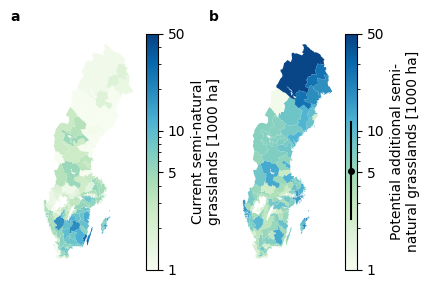


Semi-natural grassland area
(excl. wooded)
---------------------------
Baseline: 0.51 Mha (incl. 0.01 Mha meadows)
+ 0.01 Mha wooded pastures
Potential: 1.21 Mha
+ 0.05 Mha wooded pastures
Increase: 0.70 Mha
+ 0.04 Mha wooded pastures



In [7]:
import matplotlib

fig, axs = plt.subplots(1,2, figsize=(4.5,2.8))
ax = axs[0]
cm.plot.map_from_series(a0, **map_style, norm=matplotlib.colors.LogNorm(vmin=1, vmax=50), legend=False, ax=ax)
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Current semi-natural\ngrasslands [1000 ha]', fontsize=10)
cbar.set_ticks([1,5,10,50])
cbar.set_ticklabels(['1','5','10','50'])
ax.axis('off')

ax = axs[1]
cm.plot.map_from_series((a1-a0), **map_style, norm=matplotlib.colors.LogNorm(vmin=1, vmax=50), legend=False, ax=ax)
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Potential additional semi-\nnatural grasslands [1000 ha]', fontsize=10)
cbar.set_ticks([1,5,10,50])
cbar.set_ticklabels(['1','5','10','50'])
cbar.ax.plot(0.5, (a1-a0).median(), marker='.', color='black', markersize=8)
cbar.ax.plot([0.5]*2, (a1-a0).quantile([0.1, 0.9]), linewidth=1.5, color='black')
ax.axis('off')

plt.tight_layout()
annotate_axs(axs)
save_fig('Figure 1')
plt.show()

print(f"""
Semi-natural grassland area
(excl. wooded)
---------------------------
Baseline: {a0.sum()/1000:.2f} Mha (incl. {a0_meadows/1000:.2f} Mha meadows)
+ {a0_wooded/1000:.2f} Mha wooded pastures
Potential: {a1.sum()/1000:.2f} Mha
+ {a1_wooded/1000:.2f} Mha wooded pastures
Increase: {(a1-a0).sum()/1000:.2f} Mha
+ {(a1_wooded-a0_wooded)/1000:.2f} Mha wooded pastures
""")

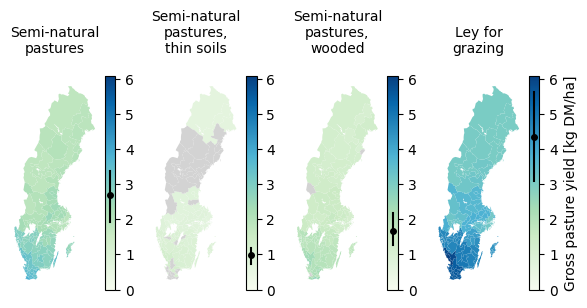


Semi-natural pastures
---------------------
Gross yield: 2.4 t DM/ha
Net yield: 1.1 t DM/ha

Ley pastures
------------
Gross yield: 4.3 t DM/ha
Net yield: 2.7 t DM/ha

Semi-natural meadows
--------------------
Gross yield: 3.2 t DM/ha
Net yield: 3.2 t DM/ha



In [8]:
from textwrap import wrap

fig, axs = plt.subplots(1,4, figsize=(6,3))
lim = y.max().max()
for ax, crp in zip(axs,y.index):
    d = y.loc[crp]
    cm.plot.map_from_series(
        d, ax=ax,
        vmin=0, vmax=lim,
        missing_kwds=dict(color="lightgray"),
        legend=False, **map_style
    )
    cbar = plt.colorbar(ax.collections[0], ax=ax)
    if ax is axs[-1]:
        cbar.set_label('Gross pasture yield [kg DM/ha]', fontsize=10)
    cbar.ax.plot(0.5, y_avg.loc[crp], marker='.', color='black', markersize=8)
    cbar.ax.plot([0.5]*2, d.quantile([0.1, 0.9]), linewidth=1.5, color='black')
    ax.set_title('\n'.join(wrap(crp, 12)), size=10)
    ax.axis('off')
plt.tight_layout()
save_fig('Figure 2')
plt.show()

print(f"""
Semi-natural pastures
---------------------
Gross yield: {y_cg_gross.loc['Semi-natural pastures']:.1f} t DM/ha
Net yield: {y_cg_net.loc['Semi-natural pastures']:.1f} t DM/ha

Ley pastures
------------
Gross yield: {y_avg.loc['Ley for grazing']:.1f} t DM/ha
Net yield: {y_avg_net.loc['Ley for grazing']:.1f} t DM/ha

Semi-natural meadows
--------------------
Gross yield: {y_cg_gross.loc['Semi-natural meadows']:.1f} t DM/ha
Net yield: {y_cg_net.loc['Semi-natural meadows']:.1f} t DM/ha
""")


In [34]:
{'a':1}|{'b':2}

{'a': 1, 'b': 2}

In [9]:
display(y_avg)
display(y_avg_net)

crop
Semi-natural pastures                2.700619
Semi-natural pastures, thin soils    0.972494
Semi-natural pastures, wooded        1.669888
Ley for grazing                      4.335644
Name: (BL, 0), dtype: float64

crop
Semi-natural pastures                1.215278
Semi-natural pastures, thin soils    0.291748
Semi-natural pastures, wooded        0.500966
Ley for grazing                      2.709778
Name: (BL, 0), dtype: float64

### SNG areas (bar)

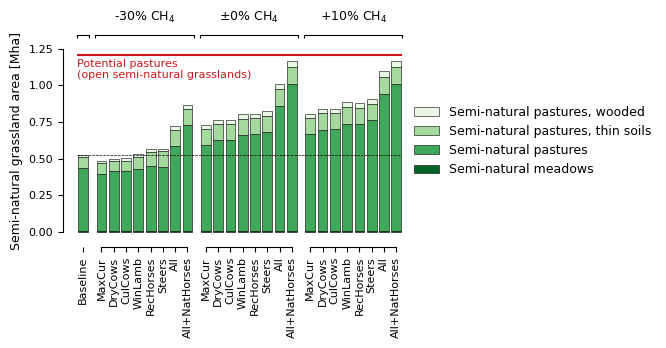

In [55]:
# SNG AREA ---------------------------------------------------------------------- ##
fig, ax = plt.subplots(figsize=(4.2,2.4))
plot_data = (
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[:,'semi-natural grasslands']
    .rename(rename_years)
)/1_000_000

max_sng = MAX_SNG.drop('Semi-natural pastures, wooded', axis=1).sum().sum() / 1_000_000

cm.plot.bar(
    plot_data.loc[sort].rename(rename_scn, level='scn'),
    ax=ax,
    group_levels='year',
    sort_xlabels=False,
    sort_groups=False,
    cmap='Greens',
    ylabel='Semi-natural grassland area [Mha]',
    ylim = (-0.01,1.25),
    **bar_style
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
ax.axhline(max_sng, c='#cb181d', linewidth=1.5, linestyle='-')
ax.text(0,max_sng*0.98,'Potential pastures\n(open semi-natural grasslands)', va='top', size=8, color='#cb181d')
_legend_r(ax)

save_fig('Figure 3', dpi=300, tight=True)
plt.show()

In [52]:
table_data = plot_data.loc[sort].rename(columns=lambda x: 'wooded' if 'wooded' in x else 'open').T.groupby('crop').sum().T
table_data['total'] = table_data.sum(axis=1)
print('Total area [Mha]')
display(table_data)
print('Change in area [Mha]')
display(table_data.sub(table_data.iloc[0], axis=1))
print('Change in area [%]')
display(table_data.sub(table_data.iloc[0], axis=1).div(table_data.iloc[0], axis=1)*100)

Total area [Mha]


crop                              open    wooded     total
scn              year                                     
BL                            0.508364  0.014796  0.523160
MAX_CUR          -30% CH$_4$  0.470295  0.013973  0.484269
                 ±0% CH$_4$   0.703350  0.025612  0.728962
                 +10% CH$_4$  0.776851  0.029467  0.806318
DRY_COWS         -30% CH$_4$  0.485944  0.014036  0.499980
                 ±0% CH$_4$   0.737800  0.027564  0.765364
                 +10% CH$_4$  0.808916  0.030582  0.839499
CUL_COWS         -30% CH$_4$  0.486812  0.014111  0.500923
                 ±0% CH$_4$   0.738586  0.027602  0.766188
                 +10% CH$_4$  0.809758  0.030628  0.840386
WIN_LAMB         -30% CH$_4$  0.512709  0.015314  0.528023
                 ±0% CH$_4$   0.772928  0.029119  0.802047
                 +10% CH$_4$  0.850009  0.032719  0.882728
REC_HORSES       -30% CH$_4$  0.545906  0.017514  0.563419
                 ±0% CH$_4$   0.775820  0.029439  0.805259
                 +10% CH$_4$  0.844034  0.032590  0.876624
STEERS           -30% CH$_4$  0.549559  0.018600  0.568159
                 ±0% CH$_4$   0.792983  0.029762  0.822745
                 +10% CH$_4$  0.873066  0.033351  0.906417
ALL              -30% CH$_4$  0.696102  0.024931  0.721032
                 ±0% CH$_4$   0.972500  0.037261  1.009761
                 +10% CH$_4$  1.055134  0.040174  1.095308
ALL + NAT_HORSES -30% CH$_4$  0.837557  0.031080  0.868637
                 ±0% CH$_4$   1.126214  0.041477  1.167691
                 +10% CH$_4$  1.126214  0.041477  1.167691

Change in area [Mha]


crop                              open    wooded     total
scn              year                                     
BL                            0.000000  0.000000  0.000000
MAX_CUR          -30% CH$_4$ -0.038069 -0.000822 -0.038891
                 ±0% CH$_4$   0.194986  0.010817  0.205803
                 +10% CH$_4$  0.268488  0.014671  0.283158
DRY_COWS         -30% CH$_4$ -0.022420 -0.000760 -0.023180
                 ±0% CH$_4$   0.229436  0.012768  0.242205
                 +10% CH$_4$  0.300552  0.015787  0.316339
CUL_COWS         -30% CH$_4$ -0.021551 -0.000685 -0.022236
                 ±0% CH$_4$   0.230222  0.012806  0.243028
                 +10% CH$_4$  0.301394  0.015832  0.317227
WIN_LAMB         -30% CH$_4$  0.004346  0.000518  0.004863
                 ±0% CH$_4$   0.264565  0.014323  0.278887
                 +10% CH$_4$  0.341646  0.017923  0.359568
REC_HORSES       -30% CH$_4$  0.037542  0.002718  0.040260
                 ±0% CH$_4$   0.267457  0.014643  0.282100
                 +10% CH$_4$  0.335670  0.017794  0.353464
STEERS           -30% CH$_4$  0.041195  0.003804  0.044999
                 ±0% CH$_4$   0.284619  0.014966  0.299586
                 +10% CH$_4$  0.364702  0.018555  0.383257
ALL              -30% CH$_4$  0.187738  0.010135  0.197873
                 ±0% CH$_4$   0.464136  0.022465  0.486601
                 +10% CH$_4$  0.546770  0.025378  0.572149
ALL + NAT_HORSES -30% CH$_4$  0.329193  0.016284  0.345477
                 ±0% CH$_4$   0.617850  0.026681  0.644531
                 +10% CH$_4$  0.617850  0.026681  0.644531

Change in area [%]


crop                                open      wooded       total
scn              year                                           
BL                              0.000000    0.000000    0.000000
MAX_CUR          -30% CH$_4$   -7.488441   -5.558032   -7.433846
                 ±0% CH$_4$    38.355621   73.105889   39.338417
                 +10% CH$_4$   52.814062   99.154058   54.124636
DRY_COWS         -30% CH$_4$   -4.410249   -5.136218   -4.430781
                 ±0% CH$_4$    45.132329   86.296511   46.296522
                 +10% CH$_4$   59.121534  106.696135   60.467024
CUL_COWS         -30% CH$_4$   -4.239342   -4.630427   -4.250403
                 ±0% CH$_4$    45.286844   86.551986   46.453893
                 +10% CH$_4$   59.287124  107.005097   60.636670
WIN_LAMB         -30% CH$_4$    0.854809    3.498782    0.929585
                 ±0% CH$_4$    52.042372   96.802498   53.308265
                 +10% CH$_4$   67.204937  121.133837   68.730138
REC_HORSES       -30% CH$_4$    7.384887   18.368659    7.695527
                 ±0% CH$_4$    52.611291   98.966469   53.922295
                 +10% CH$_4$   66.029553  120.263719   67.563388
STEERS           -30% CH$_4$    8.103454   25.709209    8.601375
                 ±0% CH$_4$    55.987351  101.151893   57.264681
                 +10% CH$_4$   71.740442  125.406081   73.258198
ALL              -30% CH$_4$   36.929839   68.498684   37.822660
                 ±0% CH$_4$    91.299958  151.835646   93.012010
                 +10% CH$_4$  107.554932  171.523139  109.364062
ALL + NAT_HORSES -30% CH$_4$   64.755391  110.060457   66.036696
                 ±0% CH$_4$   121.536979  180.329257  123.199725
                 +10% CH$_4$  121.537032  180.328893  123.199766

### Semi-natural grassland of potential

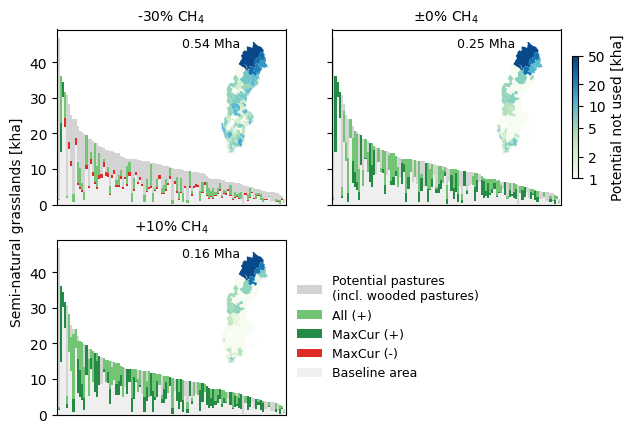

In [15]:
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

data = (
    session.get_attr('c','area',{'crop':['land_use'], 'region':None})
    .loc[:,'semi-natural grasslands']
    .stack('region')
    .sort_index()
) / 1_000

bl_sng = data.loc[('BL','0')].sort_values(ascending=False)
max_sng = MAX_SNG.sum(axis=1).sort_values(ascending=False) / 1_000

fig,axs = plt.subplots(2,2, figsize=(6.5,5))

scns = ['MAX_CUR','ALL']
for y,ax in zip(['70','100','110'], axs.flatten()):
    scn_sub = []
    scn_add = []
    for scn in scns:
        scn_sng = data.loc[(scn,y)].loc[max_sng.index]
        scn_add += [(scn_sng-bl_sng-sum(scn_add)).apply(lambda x: 0 if x<0 else x)]
        if ((scn_sng-bl_sng)<0).any():
            scn_sub += [(bl_sng-scn_sng).apply(lambda x: 0 if x<0 else x)]

    plot_data = pd.concat([bl_sng-sum(scn_sub)] + [pd.Series(sum(scn_sub))] + scn_add + [max_sng-bl_sng-sum(scn_add)], axis=1).loc[max_sng.index]\
    .rename(
        columns={0:'Baseline area',
                1:'MaxCur (-)',
                2:'MaxCur (+)',
                3:'All (+)',
                4:'Potential pastures\n(incl. wooded pastures)'}
    )
    plot_data.plot.bar(stacked=True, color=['#efefef']+['#de2d26']+['#238b45','#74c476']+['lightgrey'], width=1, legend=False, ax=ax)
    ax.set_title(rename_years[y], size=10)
    ax.set_xticks([])
    ax.set_xlabel('')
    if ax is axs[0,0]:
        ax.set_ylabel('Semi-natural grasslands [kha]', ha='right')
    elif ax is not axs[1,0]:
        ax.set_yticklabels([])

    # Map inset
    inset_ax =  inset_axes(ax, width="30%", height="70%", loc='upper right')
    inset_data = np.log10((max_sng - data.loc[('ALL',y)]).clip(lower=1e-3))
    cm.plot.map_from_series(
        inset_data,
        legend=False,
        ax=inset_ax,
        vmin=0,
        vmax=np.log10(50),
        **map_style
    )
    inset_ax.axis('off')
    if ax is axs[0, 1]:
        # Inset for colorbar next to the inset map
        cax = inset_axes(
            ax,
            width="3%", height="70%",
            loc='lower left',
            bbox_to_anchor=(1.05, 0.15, 0.9, 1),
            bbox_transform=ax.transAxes,
            borderpad=0
        )
        sm = mpl.cm.ScalarMappable(
            cmap=map_style['cmap'],
            norm=mpl.colors.Normalize(vmin=0, vmax=np.log10(50))
        )
        sm.set_array([])
        cb = plt.colorbar(sm, cax=cax, orientation='vertical', label='Potential not used [kha]')
        cb.set_ticks(np.log10([1,2,5,10,20,50]))
        cb.set_ticklabels(['1','2','5','10','20','50'])

    ax.annotate(f"{(max_sng - data.loc[('ALL',y)]).sum()/1000:.2f} Mha", (0.8,0.9), xycoords='axes fraction', ha='right', size=9)

_legend_r(ax)
axs[1,1].axis('off')
save_fig('Figure S1')
plt.show()

### Grazing

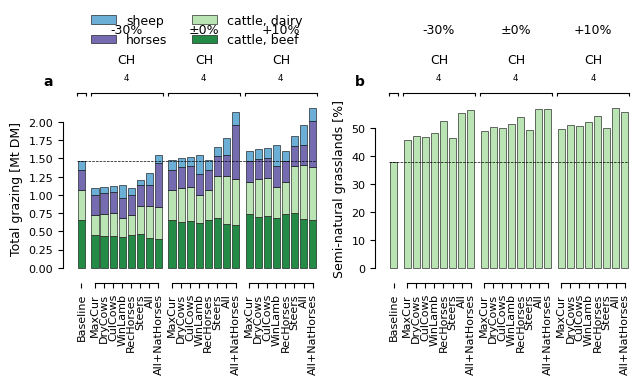

In [32]:
d1 = (
    session
    .get_attr('a','feed.crop_product_demand',['crop_prod','species','breed'])
    .loc[:,'grazing']
    .rename(rename_years)
    .loc[sort]
    /1_000_000_000
)
d1.columns = pd.Index([c[0] if c[0] != 'cattle' else ', '.join(c) for c in d1.columns], name='animal_system')
d1 = d1.T.groupby('animal_system').sum().T

d2 = (
    session
    .get_attr('c','production',{'crop_prod':None, 'crop':'land_use'})
    .loc[:,'grazing']
    .apply(lambda x: x/x.sum()*100, axis=1)
    .rename(rename_years)
    .rename(columns={'cropland':'arable'})
    .loc[sort]
)

fig,axs = plt.subplots(1,2, figsize=(6.5,4.5))
ax = axs[0]
cm.plot.bar(
    d1.rename(rename_scn, level='scn'),
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#238b45','#bae4b3', '#756bb1', '#6baed6']),
    ylabel='Total grazing [Mt DM]',
    ax=ax,
    **bar_style
)
ax.axhline(y=d1.sum(axis=1).loc['BL'].iloc[0], c='black', linewidth=0.5, linestyle='--')
_legend_t(ax)

ax = axs[1]
cm.plot.bar(
    d2.loc[:,'semi-natural grasslands'].rename(rename_scn, level='scn'),
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#bae4b3']),
    ylabel='Semi-natural grasslands [%]',
    ax=ax,
    **bar_style
)
ax.axhline(y=d2.loc['BL','semi-natural grasslands'].iloc[0], c='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
annotate_axs(axs, pos=(-0.1,1.2))
save_fig('Figure 4')
plt.show()

### Maps: LSU, SNG, Ley

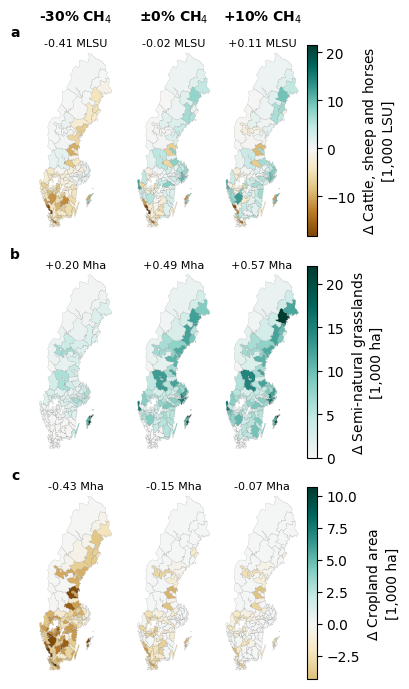

In [17]:
scn = 'ALL'

d1 = (
    cm.impact.get_LSU(session, ['species','region'])
    .apply(lambda x: x - x.loc[('BL','0')])
    .loc[scn,['cattle','sheep','horses']]
    .T.groupby('region').sum().T
) / 1_000

d2 = (
    session.get_attr('c','area',{'crop':'land_use', 'region':None})
    .apply(lambda x: x - x.loc[('BL','0')])
    .loc[scn,'semi-natural grasslands']
    .T.groupby('region').sum().T
) / 1_000

d3 = (
   session.get_attr('c','area',{'crop':'land_use', 'region':None})
    .apply(lambda x: x - x.loc[('BL','0')])
    .loc[scn,'cropland']
    .T.groupby('region').sum().T 
) / 1_000

ds = {
    '$\Delta$ Cattle, sheep and horses\n[1,000 LSU]':d1,
    '$\Delta$ Semi-natural grasslands\n[1,000 ha]':d2,
    '$\Delta$ Cropland area\n[1,000 ha]':d3
}

fig,axs = plt.subplots(3,3, figsize=(4,7))

for i,d in enumerate(ds):
    lim = ds[d].abs().max().max()
    for j,y in enumerate(['70','100','110']):
        ax = axs[i,j]
        cm.plot.map_from_series(
            ds[d].loc[y],
            ax=ax,
            vmax=lim,
            cmap_zero_midpoint='shrink',
            legend=False,
            **map_style_div
        )
        ax.axis('off')
        if i == 0:
            ax.set_title(rename_years[y], size=10, fontweight='bold')
        if j == 2:
            cbar = plt.colorbar(ax.collections[0], ax=ax)
            cbar.set_label(d, fontsize=10)
        ax.annotate(
            f"{ds[d].loc[y].sum()/1_000:+.2f} {'MLSU' if 'LSU' in d else 'Mha'}",
            (0.5,0.99),
            xycoords='axes fraction',
            size=8,
            ha='center'
        )

plt.tight_layout()
annotate_axs(axs.T[0])
save_fig('Figure 5')
plt.show()

### Climate impacts

#### GHG intensity

C:\Users\jnka0003\AppData\Local\Temp\ipykernel_23656\2765740482.py:58: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[0].scatter(
C:\Users\jnka0003\AppData\Local\Temp\ipykernel_23656\2765740482.py:67: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[1].scatter(


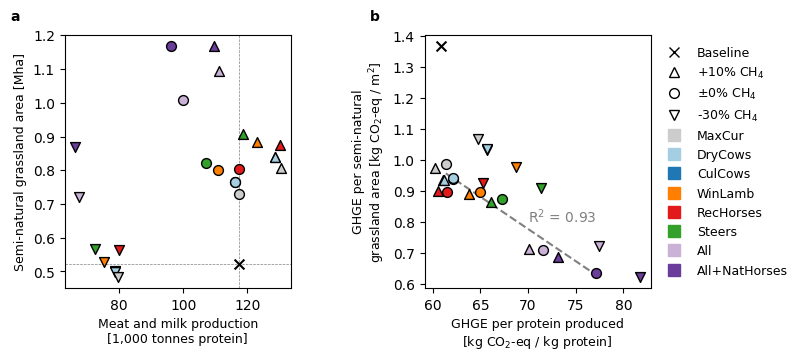

Change in protein production [%]


,,0
scn,year,
BL,0,0
ALL,100,-15
ALL + NAT_HORSES,100,-18
CUL_COWS,100,-1
DRY_COWS,100,-1
MAX_CUR,100,-0
NAT_HORSES,100,-8
REC_HORSES,100,0
STEERS,100,-9


In [18]:
from matplotlib.lines import Line2D

ghg = cm.impact.get_GHG(session, CO2eq='GWP100 AR6').T.groupby(['item','process']).sum().unstack(fill_value=0)

ghg_ani = ghg.loc[ghg.index.str.contains('cattle|sheep|horses', case=False, na=False)].sum().unstack()

prod_per_use = session.get_attr('c','production_per_use',{'demand':None,'crop':'crop_group2'})
crp_allo_factors = (
    prod_per_use.loc[:,prod_per_use.columns.get_level_values('demand').str.contains('cattle|sheep|horses', case=False, na=False)].T.groupby('crop_group2').sum()
    /
    prod_per_use.T.groupby('crop_group2').sum()
).dropna()
ghg_crp = (ghg.loc[crp_allo_factors.index] * crp_allo_factors.reindex(columns=ghg.columns)).sum().unstack()

ghg_tot = (ghg_ani + ghg_crp).replace({0:np.nan}).dropna(axis=1, how='all').fillna(0)

prod = session.get_attr('a','production',['species','animal_prod']).loc[:,(['cattle','sheep','horses'],['meat','milk'])]
# Slaughter weight --> Raw edible weight from Swedish Board of Agriculture https://jordbruksverket.se/mat-och-drycker/handel-och-marknad/priser-och-marknadsinformation-for-livsmedel 
# Raw edible weight --> Protein from Swedish Food Agency https://soknaringsinnehall.livsmedelsverket.se/
prot = pd.Series({ # [g/kg]
    ('cattle','meat') : 0.624 * 222, # "Nöt kött rå"
    ('sheep','meat') : 0.624 * 199, # "Lamm kött rå"
    ('cattle','milk') : 1 * 35 # "Mjölk fett 4,2% typ lantmjölk"
}).rename_axis(['species','animal_prod'])
prot_prod = prod.mul(prot, axis=1).sum(axis=1) / 1_000 # [kg protein]
sng = session.get_attr('c','area',{'crop':'land_use'}).loc[:,'semi-natural grasslands'] * 10_000 # [m2]

ghg_per_sng = (ghg_tot.sum(axis=1)/sng).rename('sng')
ghg_per_prot = (ghg_tot.sum(axis=1)/prot_prod).rename('prot')

plot_data = pd.concat([ghg_per_sng,ghg_per_prot], axis=1)
plot_data = plot_data.loc[sort]

fig, axs = plt.subplots(1,3, figsize=(8,3.5), width_ratios=(1,1,0))
axs[2].axis('off')

colors = {
    'BL': 'black',
    'MAX_CUR': '#cccccc',
    'DRY_COWS': '#a6cee3',
    'CUL_COWS': '#1f78b4',
    'WIN_LAMB': '#ff7f00',
    'REC_HORSES': '#e31a1c',
    'STEERS': '#33a02c',
    'ALL': '#cab2d6',
    'ALL + NAT_HORSES': '#6a3d9a'
}

markers = {
    '0': 'x',
    '110': '^',
    '100': 'o',
    '70': 'v',
}

# Loop through each combination of scenario and year
for (scn, year), group in plot_data.groupby(level=['scn', 'year']):
    axs[0].scatter(
        prot_prod.loc[(scn,year)] / 1_000_000,
        sng.loc[(scn,year)] / 10_000 / 1_000_000,
        color=colors.get(scn, 'gray'),
        marker=markers.get(year, 'x'),
        edgecolor='black',
        s=50,
        label=f'{rename_scn(scn)} {rename_years[year]}'
    )
    axs[1].scatter(
        group['prot'],
        group['sng'],
        color=colors.get(scn, 'gray'),
        marker=markers.get(year, 'x'),
        edgecolor='black',
        s=50,
        label=f'{rename_scn(scn)} {rename_years[year]}'
    )

# Baseline lines
axs[0].axvline(prot_prod.loc[('BL','0')] / 1_000_000, linestyle='--', color='grey', linewidth=0.5, zorder=0)
axs[0].axhline(sng.loc[('BL','0')] / 10_000 / 1_000_000, linestyle='--', color='grey', linewidth=0.5, zorder=0)

# Create linear model
from scipy.stats import linregress
y,x = plot_data.xs('100', level='year').values.T
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r2_value = r_value**2
x_vals = np.linspace(x.min(), x.max(), 100)
y_vals = slope * x_vals + intercept
axs[1].plot(x_vals, y_vals, color='grey', linestyle='--', zorder=0)
axs[1].annotate(f'R$^2$ = {r2_value:.2f}', (70,0.8), color='grey')

# Legend for scenarios (color)
scn_legend = [
    Line2D([0], [0], color=color, marker='s', linestyle='None', markersize=8, label=rename_scn(scn))
    for scn, color in colors.items() if scn != 'BL'
]

# Legend for years (marker)
year_legend = [
    Line2D([0], [0], color='white', markeredgecolor='black', marker=marker, linestyle='None', markersize=7, label=rename_years[year] if year != '0' else 'Baseline')
    for year, marker in markers.items()
]

# Add legends to the plot
legend1 = axs[1].legend(handles=scn_legend, title="", loc='lower left', fontsize=9, bbox_to_anchor=(1, 0), frameon=False)
legend2 = axs[1].legend(handles=year_legend, title="", loc='upper left', fontsize=9, bbox_to_anchor=(1, 1), frameon=False)
axs[1].add_artist(legend1)  # Make sure the first legend stays
axs[0].set_xlabel('Meat and milk production\n[1,000 tonnes protein]', size=9)
axs[0].set_ylabel('Semi-natural grassland area [Mha]', size=9)
axs[1].set_xlabel('GHGE per protein produced\n[kg CO$_2$-eq / kg protein]', size=9)
axs[1].set_ylabel('GHGE per semi-natural\ngrassland area [kg CO$_2$-eq / m$^2$]', size=9)

plt.tight_layout()
annotate_axs(axs[0:2])
save_fig('Figure 6')
plt.show()

print('Change in protein production [%]')
display(prot_prod.sub(prot_prod.iloc[0]).div(prot_prod.iloc[0]).mul(100).sort_index(level='year').to_frame().style.format(precision=0))

#### Entric CH$_4$ per ha SNG

In [57]:
display(
    session.get_attr('a','enteric_methane','none')/
    session.get_attr('c','area',{'crop':'land_use'})
    .loc[:,'semi-natural grasslands']
)
display(
    session_sens.get_attr('a','enteric_methane','none')/
    session_sens.get_attr('c','area',{'crop':'land_use'})
    .loc[:,'semi-natural grasslands']
)

scn               year
BL                0       206.584517
MAX_CUR           70      156.222502
                  100     148.260990
                  110     147.441042
STEERS            70      133.155922
                  100     131.361038
                  110     131.158567
CUL_COWS          70      151.028481
                  100     141.057717
                  110     141.463944
DRY_COWS          70      151.313533
                  100     141.209452
                  110     141.613500
REC_HORSES        70      134.275923
                  100     134.213512
                  110     135.616122
NAT_HORSES        70      128.861316
                  100      93.304094
                  110     102.475682
ALL               70      104.924083
                  100     107.031950
                  110     108.539626
ALL + NAT_HORSES  70       87.094700
                  100      92.555901
                  110     101.811473
WIN_LAMB          70      143.277277
               

scn                   year
BL                    0       206.584517
MAX_CUR + FIX_ANI     100     157.290790
ALL + MORE_WOODED     70       90.938718
                      100      91.229395
                      110      92.291841
ALL + LOW_YIELDS      70       79.102443
                      100      91.810989
                      110     100.552858
ALL + HIGH_SHARE_SNG  70       73.694420
                      100      90.460566
                      110      99.506622
ALL + MORE_POT        70      102.091832
                      100     104.662454
                      110     105.796111
ALL + MORE_CROPLAND   70      104.782704
                      100     106.702913
                      110     108.163488
dtype: float64

#### Total GHG

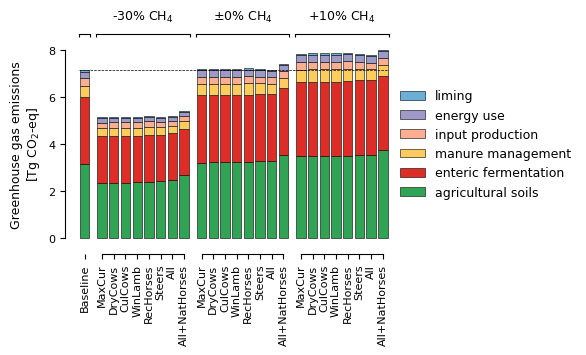

In [58]:
plot_data = ghg_tot.rename(rename_years)/1_000_000_000

fig, ax = plt.subplots(figsize=(4,2.5))
cm.plot.bar(
    plot_data.loc[sort].rename(rename_scn, level='scn'),
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#31a354','#de2d26', '#fecc5c', '#fcae91', '#9e9ac8', '#6baed6', '#969696']),
    ylabel='Greenhouse gas emissions\n[Tg CO$_2$-eq]',
    **bar_style
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)
plt.show()

### Herd size

species,"cattle, beef","cattle, dairy","horses, cons.","horses, recr.",pigs,poultry,sheep
scn,,,,,,,
MAX_CUR,-0,-0,0,-0,0,0,3
DRY_COWS,-19,21,0,-0,0,0,2
CUL_COWS,-14,9,0,-0,0,0,2
WIN_LAMB,-29,-43,0,-0,0,0,53
REC_HORSES,0,0,0,0,-0,0,3
STEERS,-14,6,0,-0,-0,0,-1
ALL,-66,0,0,0,0,0,44
ALL + NAT_HORSES,-81,-26,213,-0,0,0,29


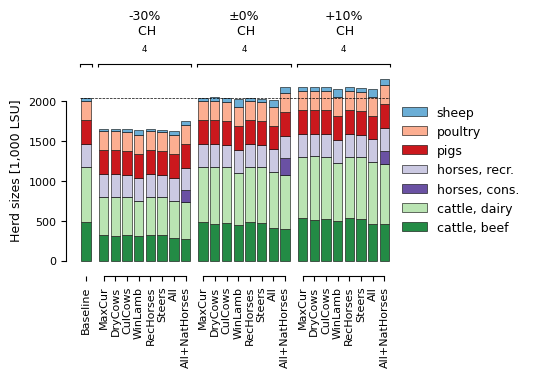

In [45]:
plot_data = (
    cm.impact.get_LSU(session, ['species','breed','animal'])
    .rename(rename_years)
) / 1_000

plot_data.columns = pd.Index(
    [f'{sp}, {br}' if sp == 'cattle'
     else 'horses, recr.' if sp == 'horses' and 'cons' not in br
     else 'horses, cons.' if sp == 'horses'
     else sp
     for sp,br,an in plot_data.columns],
    name = 'species'
)

plot_data = plot_data.T.groupby('species').sum().T

display(plot_data.loc[sort].sub(plot_data.loc[('BL','')], axis=1).xs('±0% CH$_4$', level='year').style.format('{:,.0f}'))

fig, ax = plt.subplots(figsize=(4,2.4))
cm.plot.bar(
    plot_data.loc[sort].rename(rename_scn, level='scn'),
    ax=ax,
    group_levels='year',
    sort_xlabels=False,
    sort_groups=False,
    cmap=ListedColormap(name='X', colors=['#238b45','#bae4b3', '#6a51a3', '#cbc9e2', '#cb181d', '#fcae91', '#6baed6']),
    ylabel='Herd sizes [1,000 LSU]',
    **bar_style
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)
save_fig('Figure S2')
plt.show()

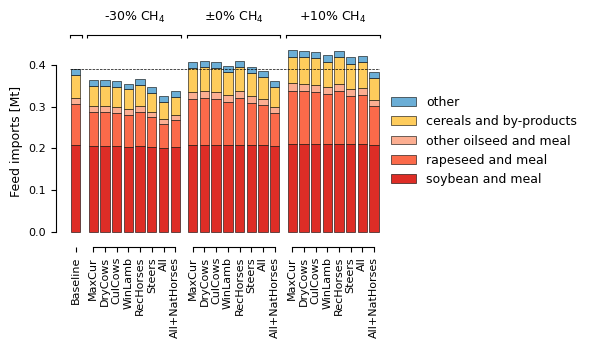

In [60]:
by_prod_agg = {
    'fish meal' : 'other',
    'luzern meal' : 'other',
    'potatoe protein' : 'other',
    'sugar beet molasses' : 'other',
    'sugar beet pulp' : 'other',
    
    'wheat distillers grain' : 'cereals and by-products',
    'maize gluten meal' : 'cereals and by-products',
    'milling by-products from wheat, barley or rye' : 'cereals and by-products',
    
    'soybean meal' : 'soybean and meal',
    'soybean protein concentrate' : 'soybean and meal',
    
    'rapeseed cake' : 'rapeseed and meal',
    'rapeseed meal' : 'rapeseed and meal',
    
    'palm kernel expeller' : 'other oilseed and meal',
    'sunflower seed meal' : 'other oilseed and meal',
}

crop_prod_agg = {
    'linseed' : 'other oilseed and meal',
    'maize' : 'cereals and by-products',
    'soybeans' : 'soybean and meal'
}

plot_data = pd.concat([
    (
        session.get_attr('a','feed.crop_prod',['origin','crop_prod'])
        .loc[:,'imported']
        .rename(columns = crop_prod_agg)
        .rename_axis(columns = 'item')
        .rename(rename_years)
    ),
    (
        session.get_attr('d','by_products',['origin','by_prod'])
        .loc[:,'imported']
        .rename(columns = by_prod_agg)
        .rename_axis(columns = 'item')
        .rename(rename_years)
    )
], axis=1).T.groupby('item').sum().T / 1_000_000_000

item_sort = ['soybean and meal', 'rapeseed and meal', 'other oilseed and meal', 'cereals and by-products', 'other']

fig, ax = plt.subplots(figsize=(4,2.4))
cm.plot.bar(
    plot_data.loc[sort,item_sort].rename(rename_scn, level='scn'),
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#de2d26','#fb6a4a', '#fcae91', '#fecc5c', '#6baed6']),
    ylabel='Feed imports [Mt]',
    **bar_style
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)

plt.show()

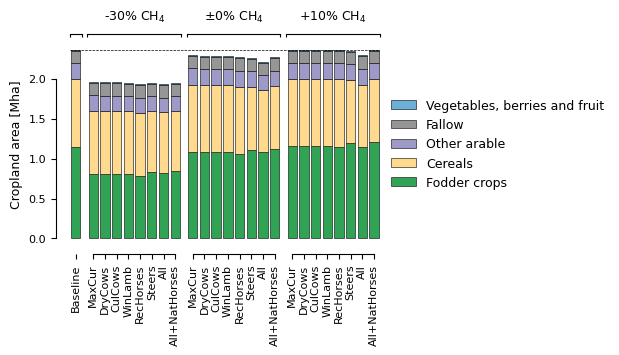

In [61]:
# CROP AREA ---------------------------------------------------------------------- ##

fig, ax = plt.subplots(figsize=(4,2.5))
plot_data = (
    session.get_attr('c','area',{'crop':['land_use','crop_group2']})
    .loc[:,'cropland']
    .rename(rename_years)
)/1000000
cm.plot.bar(
    plot_data.loc[sort].rename(rename_scn, level='scn'),
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#31a354','#fed98e', '#9e9ac8', '#969696', '#6baed6']),
    ylabel='Cropland area [Mha]',
    **bar_style
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)

plt.show()

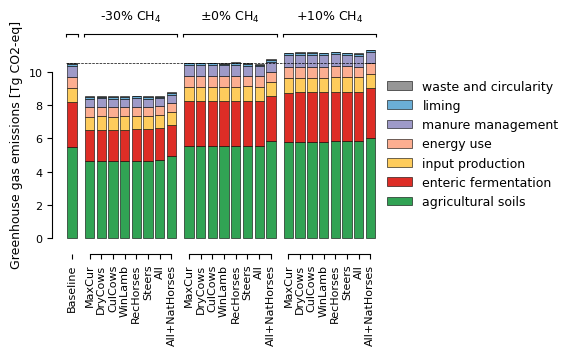

In [62]:
# GHG ---------------------------------------------------------------------- ##

fig, ax = plt.subplots(figsize=(4,2.5))
plot_data = (
    cm.impact.get_GHG(session)
    .T.groupby('process').sum().T
    .rename(rename_years)
)/1000000000
cm.plot.bar(
    plot_data.loc[sort].rename(rename_scn, level='scn'),
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#31a354','#de2d26', '#fecc5c', '#fcae91', '#9e9ac8', '#6baed6', '#969696']),
    ylabel='Greenhouse gas emissions [Tg CO2-eq]',
    **bar_style
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)

plt.show()

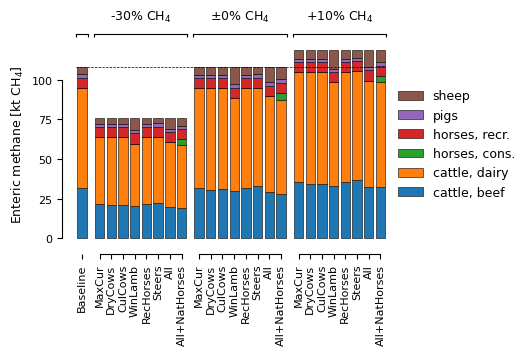

In [63]:
plot_data = (
    session.get_attr('a','enteric_methane',['species','breed'])
    .rename(rename_years)
    /1_000_000
)

plot_data.columns = pd.Index(
    [f'{sp}, {br}' if sp == 'cattle'
     else 'horses, recr.' if sp == 'horses' and 'cons' not in br
     else 'horses, cons.' if sp == 'horses'
     else sp
     for sp,br in plot_data.columns],
    name = 'species'
)

plot_data = plot_data.T.groupby('species').sum().T

fig, ax = plt.subplots(figsize=(4,2.5))
cm.plot.bar(
    plot_data.loc[sort].rename(rename_scn, level='scn'),
    group_levels='year',
    ylabel='Enteric methane [kt CH$_4$]',
    ax=ax,
    **bar_style
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)

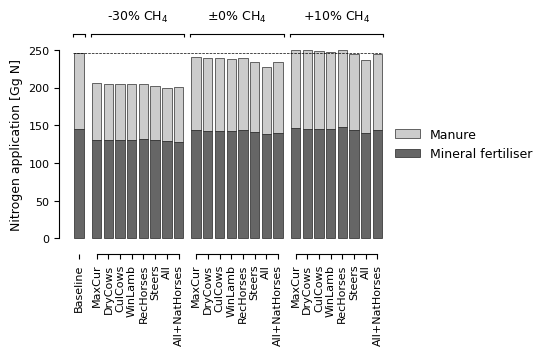

In [64]:
# N FERTILISER ---------------------------------------------------------------------- ##

fig, ax = plt.subplots(figsize=(4,2.5))
plot_data = (
    pd.concat([
        session.get_attr('c','fertiliser.mineral_N', {'crop':'land_use'}).loc[:,'cropland'].rename('Mineral fertiliser'),
        session.get_attr('c','fertiliser.manure_N', {'crop':'land_use'}).loc[:,'cropland'].rename('Manure')
    ], axis=1)
    .rename(rename_years)
)/1000000

cm.plot.bar(
    plot_data.loc[sort].rename(rename_scn, level='scn'),
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#666666','#cccccc']),
    ylabel='Nitrogen application [Gg N]',
    **bar_style
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)

plt.show()

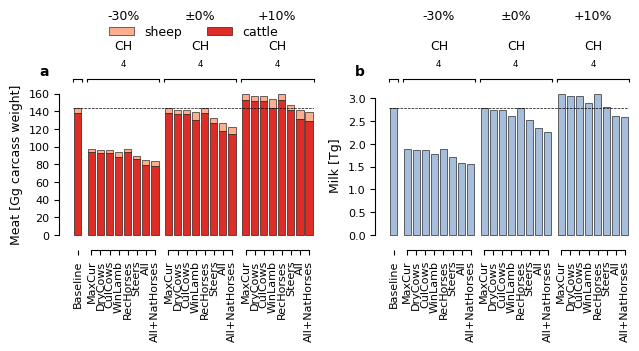

In [48]:
# MEAT AND MILK ---------------------------------------------------------------------- ##
fig, axs = plt.subplots(1,2, figsize=(6.5,4))
plot_data = (
    session.get_attr('a','prod', ['animal_prod','species'])
    .loc[:,(slice(None),['cattle','sheep'])]
    .rename(rename_years)
)/1000000
ax = axs[0]
cm.plot.bar(
    plot_data.loc[:,'meat'].loc[sort].rename(rename_scn, level='scn'),
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#de2d26','#fcae91']),
    ylabel='Meat [Gg carcass weight]',
    **bar_style
)
ax.axhline(plot_data.loc[('BL',''),'meat'].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_t(ax)
ax = axs[1]
cm.plot.bar(
    plot_data.loc[:,'milk'].loc[sort].rename(rename_scn, level='scn')/1000,
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#a6bddb']),
    ylabel='Milk [Tg]',
    **bar_style
)
ax.axhline(plot_data.loc[('BL',''),'milk'].sum()/1000, c='black', linewidth=0.5, linestyle='--')
# _legend_t(ax)

plt.tight_layout()
annotate_axs(axs, pos=(-0.1,1.2))
save_fig('Figure S3')
plt.show()

### Detailed grazing

#### Maximum grazing in SNG per animal category

In [66]:
def get_max_sng(par1,par2, sp,br,ss,an):
    max_f = par1.get(
        'max_crop_in_crop_prod',
        crop_group = 'Semi-natural pastures',
        crop_prod = 'grazing',
        species = sp,
        breed = br,
        sub_system = ss,
        animal = an
    )
    max_f *= par2.get('max_sng_adj')
    return max_f[0]/100
    

In [67]:
grazing_intake = (
    session.get_attr('a', 'feed.consumption',['feed','species','breed','sub_system','animal'])
    .loc[:,'grazing']
    .loc[:,['cattle','sheep','horses']]
)
max_sng_intake = grazing_intake.copy()

In [68]:
grazing_intake = (
    session.get_attr('a', 'feed.consumption',['feed','species','breed','sub_system','animal'])
    .loc[:,'grazing']
    .loc[:,['cattle','sheep','horses']]
)
max_sng_intake = grazing_intake.copy()

for i in max_sng_intake.index.unique('scn'):
    scn = i
    print(scn)
    par1 = cm.ParameterRetriever('FeedMgmt')
    par2 = cm.ParameterRetriever('GeoDistributor')
    for par in [par1,par2]:
        par.update_parameter_values(scenario_workbooks=session[scn]['scenario_workbooks'], year='0')
    for j in max_sng_intake.columns:
        sp,br,ss,an = j
        f = get_max_sng(par1,par2, sp,br,ss,an)
        max_sng_intake.loc[[i],[j]] *= f

grazing_intake = grazing_intake.T.groupby(['species','breed','animal']).sum().T
max_sng_intake = max_sng_intake.T.groupby(['species','breed','animal']).sum().T

BL
MAX_CUR
STEERS
CUL_COWS
DRY_COWS
REC_HORSES
NAT_HORSES
ALL
ALL + NAT_HORSES
WIN_LAMB


In [69]:
net_sng_yield = (
    session.get_attr('c','production',{'crop':'crop_group'}).loc[:,'Semi-natural pastures'] /
    session.get_attr('c','area',{'crop':'crop_group'}).loc[:,'Semi-natural pastures']
)
max_sng_area = max_sng_intake.div(net_sng_yield, axis=0)

In [72]:
max_sng_area_per_head = max_sng_area / session.get_attr('a','heads',['species','breed','animal']).loc[:,['cattle','sheep','horses']]

In [73]:
slaughtered_heads = session.get_attr('a', 'slaughtered_n', ['species','breed','animal'])

In [76]:
print('Maximum area [ha] of semi-natural grasslands grazed per steer lifetime:')
for br in ['dairy','beef']:
    slaughtered_cattle = slaughtered_heads.loc[:,('cattle',br)].sum(axis=1)
    slaughtered_steers = slaughtered_heads.loc[:,('cattle',br,'steers')]
    steers_max_sng_area = (
        max_sng_area.loc[:,('cattle',br,'steers')] +
        max_sng_area.loc[:,('cattle',br,'calves, steer')] +
        (
            max_sng_area.loc[:,('cattle',br,'calves, suckling')] * (slaughtered_steers / slaughtered_cattle)
            if br == 'beef' else 0
        )
    )
    print(br)
    print('-'*len(br))
    print(steers_max_sng_area / slaughtered_steers)

Maximum area [ha] of semi-natural grasslands grazed per steer lifetime:
dairy
-----
scn               year
BL                0       1.094886
MAX_CUR           70      1.118126
                  100     1.171261
                  110     1.173237
STEERS            70      1.194068
                  100     1.196535
                  110     1.193750
CUL_COWS          70      1.105879
                  100     1.175182
                  110     1.167873
DRY_COWS          70      1.104747
                  100     1.175220
                  110     1.167960
REC_HORSES        70      1.135286
                  100     1.173808
                  110     1.168147
NAT_HORSES        70      1.160408
                  100     1.115561
                  110     1.115936
ALL               70      1.193947
                  100     1.185918
                  110     1.169394
ALL + NAT_HORSES  70      1.190448
                  100     1.143433
                  110     1.143433
WIN_LAMB          

#### Grazing per species

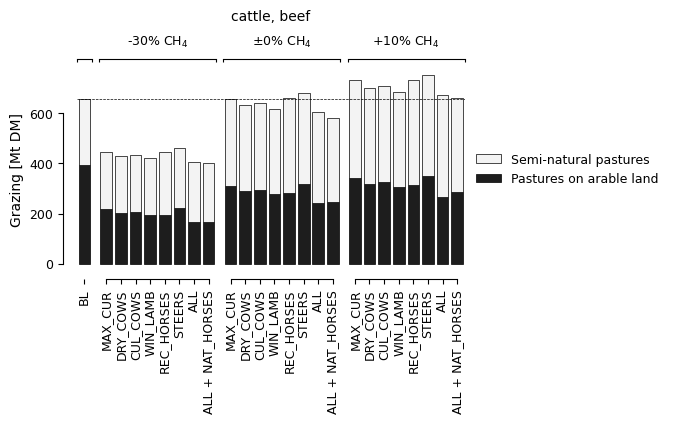

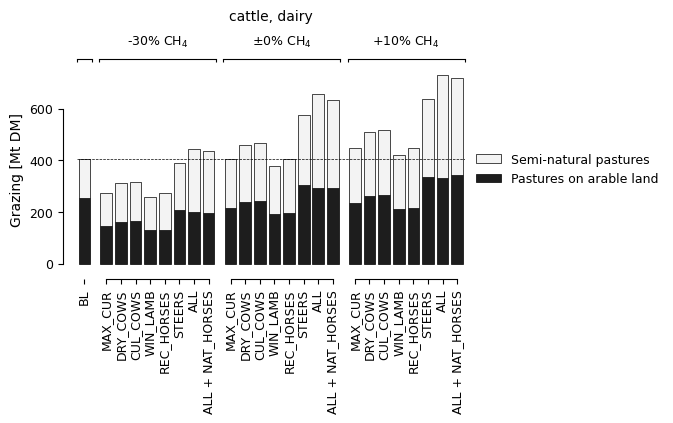

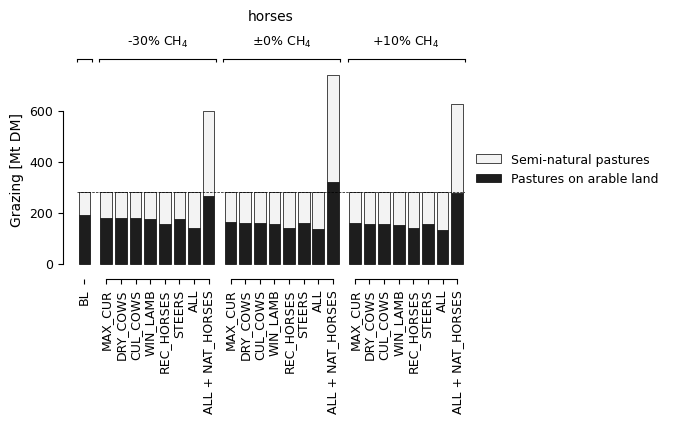

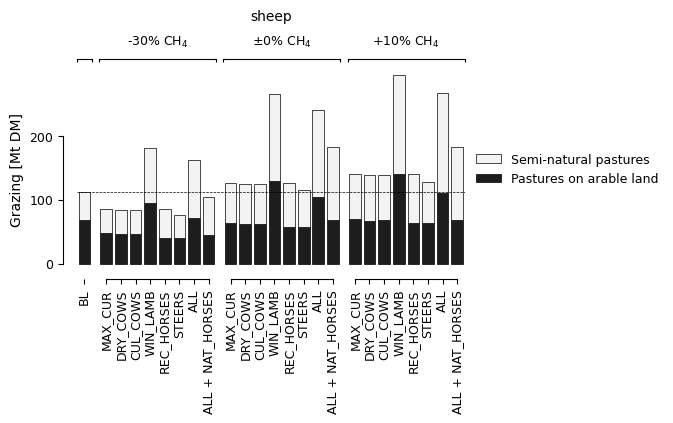

In [77]:
rename_crp = {
    'Ley for grazing' : 'Pastures on arable land',
    'Semi-natural pastures' : 'Semi-natural pastures',
    'Semi-natural pastures, thin soils' : 'Semi-natural pastures',
    'Semi-natural pastures, wooded' : 'Semi-natural pastures'
}

plot_data = (
    session.get_attr('c','production_per_use', ['crop', 'demand'])
    .rename(rename_years)
    .loc[sort,list(rename_crp)]
    .rename(columns=rename_crp, level='crop')
    .rename(
        columns=lambda x:
            'cattle, dairy' if 'cattle, dairy' in x else
            'cattle, beef' if 'cattle, beef' in x else
            'sheep' if 'sheep' in x else
            'horses' if 'horses' in x else
            '',
        level='demand'
    )
    .T.groupby(['crop','demand']).sum().T
    .rename_axis(columns={'demand':'animal_system'})
    .stack('animal_system')
)/1_000_000

for ani in plot_data.index.unique('animal_system'):
    fig,ax = plt.subplots(figsize=(5,2.5))
    d = plot_data.xs(ani, level='animal_system').replace({0:np.nan}).dropna(axis=1)
    cm.plot.bar(
        d,
        ax=ax,
        group_levels=['year'],
        sort_groups=False,
        sort_xlabels=False,
        sort_categories=False,
        grouptitle=ani,
        ylabel='Grazing [Mt DM]',
        ticklabels_fontsize=9,
        grouptitle_fontsize=10,
        grouplabels_fontsize=9,
        ylabel_fontsize=10,
        cmap='Greys'
    )
    ax.axhline(d.loc['BL'].sum(axis=1).iloc[0], c='black', linewidth=0.5, linestyle='--')
    ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False, ncol=1, fontsize=9, reverse=True)
    plt.show()

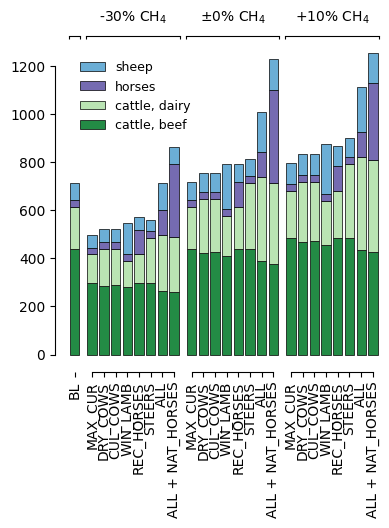

In [78]:
plot_data = (
    session
    .get_attr('a','feed.max_supply_from_crop_group',['crop_group','species','breed'])
    .rename(rename_years)
    .loc[sort,'Semi-natural pastures']
)/1_000_000
plot_data.columns = pd.Index([c[0] if c[0] != 'cattle' else ', '.join(c) for c in plot_data.columns], name='animal_system')
plot_data = plot_data.T.groupby('animal_system').sum().T

fig, ax = plt.subplots(figsize=(4,4))
cm.plot.bar(
    plot_data,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#238b45','#bae4b3', '#756bb1', '#6baed6']),
    ax=ax
)
plt.show()

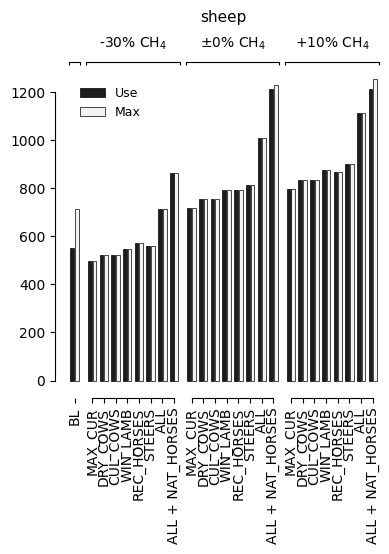

In [79]:
use_df = (
    session.get_attr('c','production', {'crop':'crop_group'})
    .rename(rename_years)
    .loc[sort,'Semi-natural pastures']
    .rename('Use')
)/1_000_000

max_df = (
    session
    .get_attr('a','feed.max_supply_from_crop_group',['crop_group'])
    .rename(rename_years)
    .loc[sort,'Semi-natural pastures']
    .rename('Max')
)/1_000_000

plot_data = pd.concat([use_df,max_df], axis=1)

fig, ax = plt.subplots(figsize=(4,4))
cm.plot.bar(
    plot_data,
    stacked=False,
    group_levels='year',
    cmap='Greys',
    grouptitle=ani,
    ax=ax
)
plt.show()

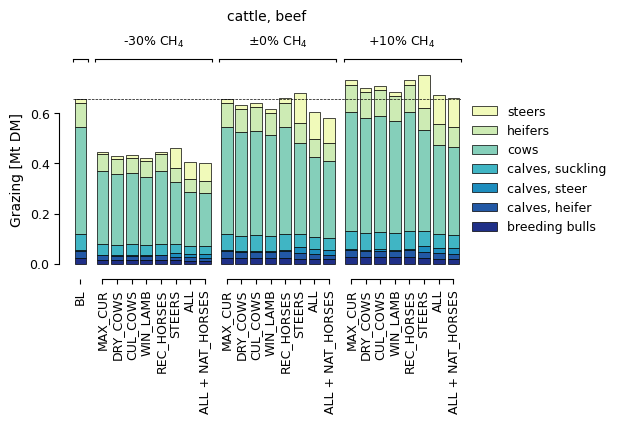

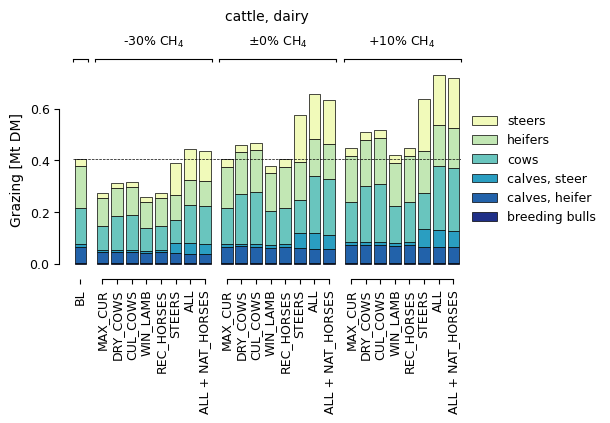

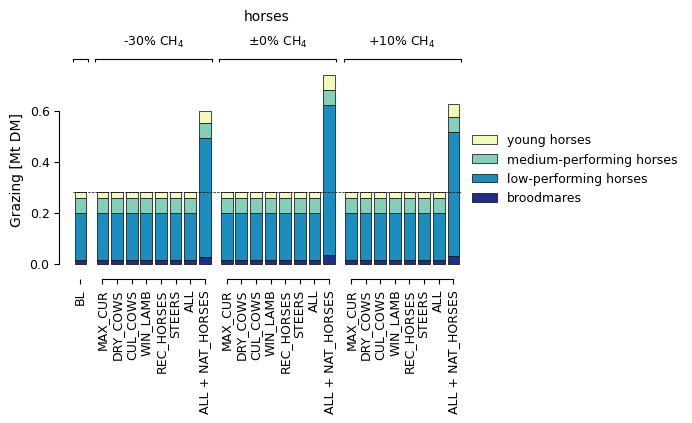

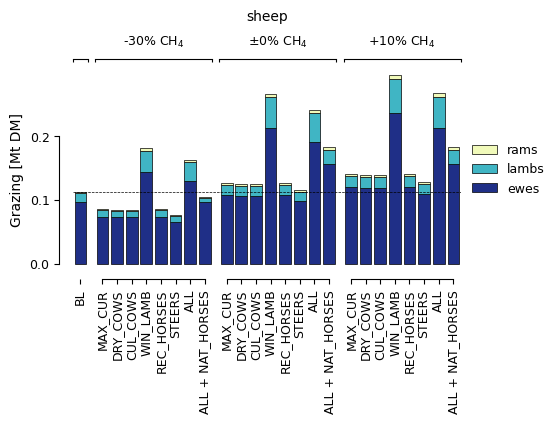

In [80]:
plot_data = (
    session.get_attr('a','feed.crop_prod',['origin','crop_prod','species','breed','animal'])
    .rename(rename_years)
    .loc[sort,('domestic','grazing')]
    .stack(['species','breed'])
)/1_000_000_000
plot_data.index = pd.MultiIndex.from_tuples(
    [( scn, y, sp if sp != 'cattle' else ', '.join([sp,br]) ) for scn,y,sp,br in plot_data.index],
    names = ['scn', 'year', 'animal_system']
)
plot_data = plot_data.groupby(['scn', 'year', 'animal_system'], sort=False).sum()

for ani in plot_data.index.unique('animal_system'):
    fig,ax = plt.subplots(figsize=(5,2.5))
    d = plot_data.xs(ani, level='animal_system').replace({0:np.nan}).dropna(axis=1)
    cm.plot.bar(
        d,
        ax=ax,
        group_levels=['year'],
        sort_groups=False,
        sort_xlabels=False,
        sort_categories=False,
        grouptitle=ani,
        ylabel='Grazing [Mt DM]',
        ticklabels_fontsize=9,
        grouptitle_fontsize=10,
        grouplabels_fontsize=9,
        ylabel_fontsize=10,
        cmap='YlGnBu'
    )
    ax.axhline(d.loc['BL'].sum(axis=1).iloc[0], c='black', linewidth=0.5, linestyle='--')
    ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False, ncol=1, fontsize=9, reverse=True)
    plt.show()

### Maps: Changes in semi-natural grassland and cropland area

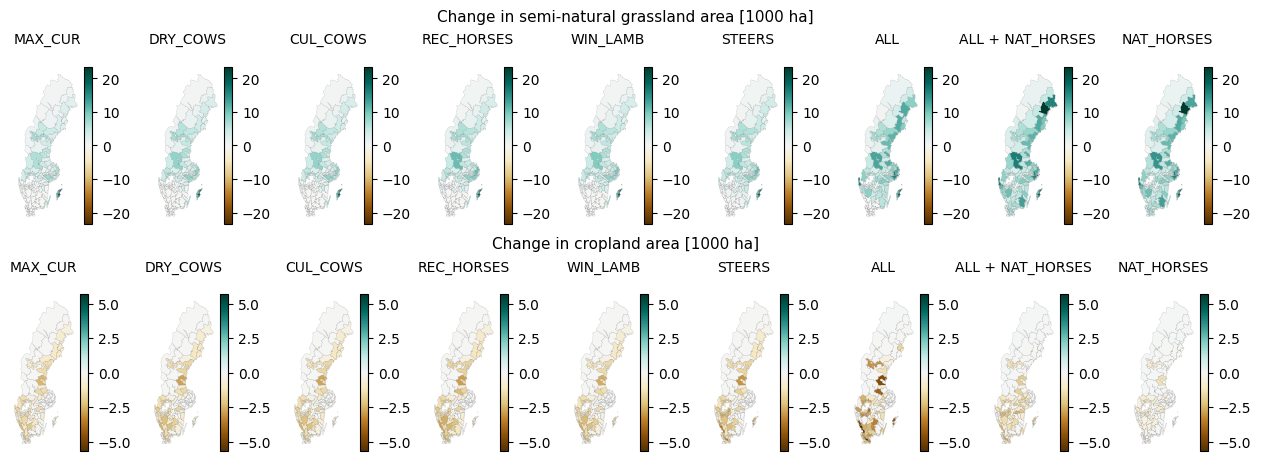

In [81]:
plot_data = (
    session.get_attr('c','area',{'crop':'land_use', 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('BL','0')],axis=1))
    .drop(('BL','0'))
    .droplevel('year')
)/1000

scn_sorted = plot_data.sum(axis=1).sort_values().index

n_scn = len(plot_data)
lims = plot_data.T.abs().groupby('land_use').max().max(axis=1)

fig = plt.figure(layout='constrained', figsize=(1.4*n_scn, 4.5))
subfigs = fig.subfigures(2, 1, wspace=0.07)

# Semi-natural grasslands
axs1 = subfigs[0].subplots(1,n_scn)
for n, scn in enumerate(plot_data.sum(axis=1).sort_values().index):
    ax = axs1[n]
    cm.plot.map_from_series(
        plot_data.loc[scn,'semi-natural grasslands'],
        ax = ax,
        vmin=-lims.loc['semi-natural grasslands'],
        # cmap_zero_midpoint='shrink',
        vmax=lims.loc['semi-natural grasslands'],
        **map_style_div
    )
    ax.set_title(scn, size=10)
    ax.axis('off')
subfigs[0].suptitle('Change in semi-natural grassland area [1000 ha]', size=11)

# Cropland
axs2 = subfigs[1].subplots(1,n_scn)
# fig, axs = plt.subplots(1,n_scn, figsize=(2.2*n_scn,4))
for n, scn in enumerate(plot_data.sum(axis=1).sort_values().index):
    ax = axs2[n]
    cm.plot.map_from_series(
        plot_data.loc[scn,'cropland'],
        ax = ax,
        vmin=-lims.loc['cropland'],
        # cmap_zero_midpoint='shrink',
        vmax=lims.loc['cropland'],
        **map_style_div
    )
    ax.set_title(scn, size=10)
    ax.axis('off')
subfigs[1].suptitle('Change in cropland area [1000 ha]', size=11)

# fig.tight_layout()
plt.show()

### Changes in yields

In [105]:
d1.xs(crp, level='crop')

scn
BL                  0.000000
MAX_CUR             0.258027
DRY_COWS            0.354917
CUL_COWS            0.355192
WIN_LAMB            0.380680
REC_HORSES          0.289010
STEERS              0.521891
ALL                 0.542262
ALL + NAT_HORSES    0.162705
dtype: float64

In [104]:
d2

scn               year
BL                0       0.523160
MAX_CUR           100     0.728962
STEERS            100     0.822745
CUL_COWS          100     0.766188
DRY_COWS          100     0.765364
REC_HORSES        100     0.805259
NAT_HORSES        100     1.158327
ALL               100     1.009761
ALL + NAT_HORSES  100     1.167691
WIN_LAMB          100     0.802047
Name: semi-natural grasslands, dtype: float64

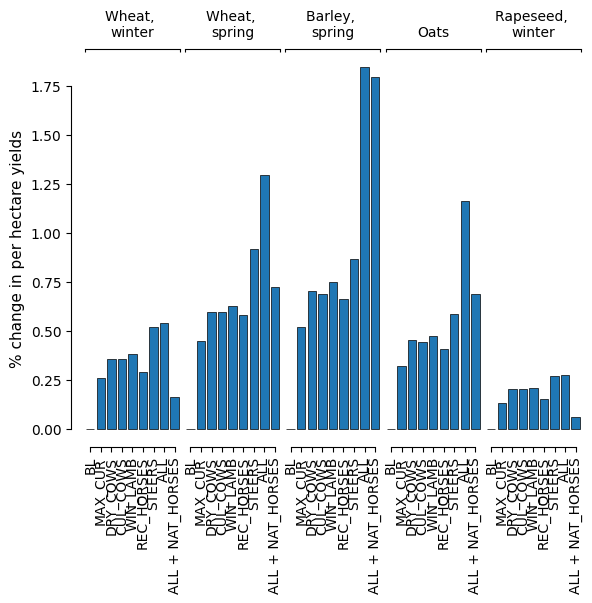

In [118]:
crps = ['Wheat, winter','Wheat, spring', 'Barley, spring','Oats','Rapeseed, winter']#, 'Ley for fodder', 'Ley for grazing']
d1=(
    (
    session.get_attr('c','harvest',{'crop':None}) /
    session.get_attr('c','area',{'crop':None})
    )
    .loc[scn_final,crps]
    .stack()
    .droplevel('year')
    .groupby('crop').apply(lambda x: (x-x.loc['BL'])/x.loc['BL']*100).droplevel(0)
    .loc[(sort,crps)]
)

cm.plot.bar(d1, group_levels='crop', ylabel='% change in per hectare yields')
plt.show()

# d2 = (
#     session.get_attr('c','area',{'crop':'land_use'})
#     .loc[scn_final,'semi-natural grasslands']
#     .loc[sort]
# )/1_000_000
# fig,ax = plt.subplots()
# for crp in d1.index.unique('crop'):
#     ax.plot(d2,d1.xs(crp, level='crop'), linestyle='', marker='o', label=crp)

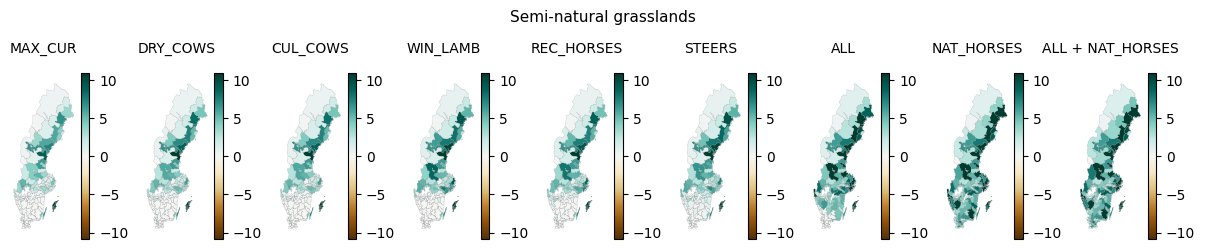

,0,1
scn,,
MAX_CUR,205.8,168.9
DRY_COWS,242.2,202.4
CUL_COWS,243.0,203.2
WIN_LAMB,278.9,234.5
REC_HORSES,282.1,243.1
STEERS,299.6,263.1
ALL,486.6,459.6
NAT_HORSES,635.2,655.9
ALL + NAT_HORSES,644.5,663.6


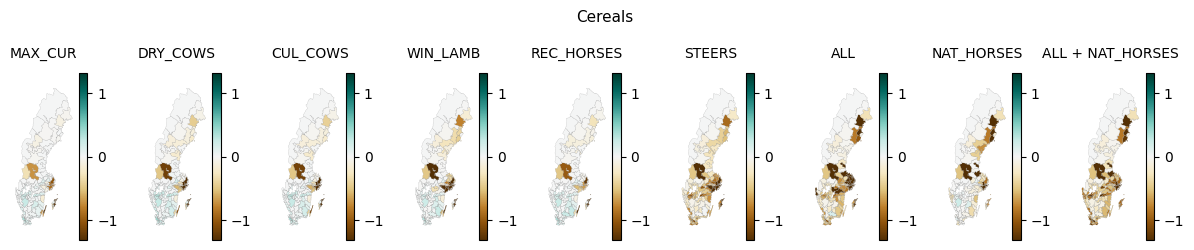

,0,1
scn,,
MAX_CUR,-4.5,-14.6
DRY_COWS,-6.5,-19.0
CUL_COWS,-7.7,-25.7
WIN_LAMB,-17.7,-68.1
REC_HORSES,-5.5,-17.3
STEERS,-53.4,-259.8
ALL,-67.9,-309.2
NAT_HORSES,-24.2,-87.5
ALL + NAT_HORSES,-61.0,-293.8


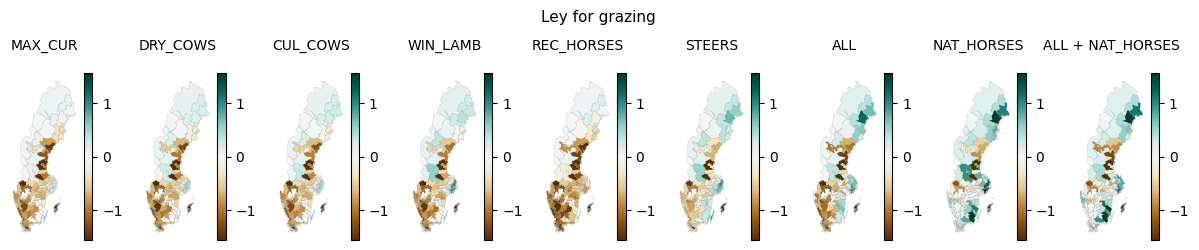

,0,1
scn,,
MAX_CUR,-58.6,-159.9
DRY_COWS,-59.9,-164.7
CUL_COWS,-55.5,-152.7
WIN_LAMB,-53.6,-152.6
REC_HORSES,-83.9,-232.9
STEERS,-26.6,-73.8
ALL,-47.8,-136.1
NAT_HORSES,8.5,31.6
ALL + NAT_HORSES,0.2,12.0


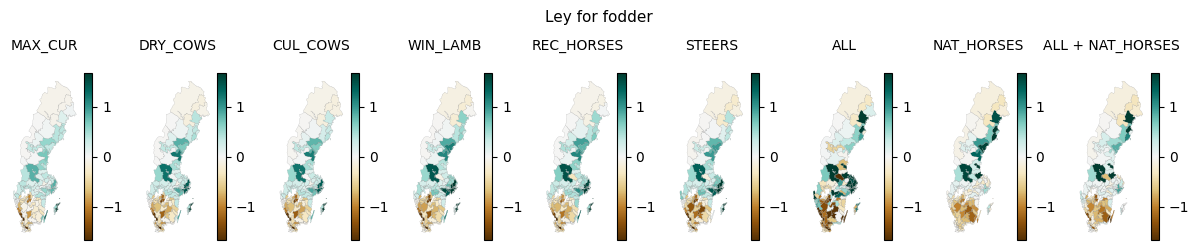

,0,1
scn,,
MAX_CUR,-0.5,-40.6
DRY_COWS,-4.5,-73.4
CUL_COWS,-6.1,-82.7
WIN_LAMB,-1.6,-67.2
REC_HORSES,1.4,-45.2
STEERS,-3.8,-73.5
ALL,-11.9,-146.2
NAT_HORSES,-10.2,-91.5
ALL + NAT_HORSES,-12.7,-102.6


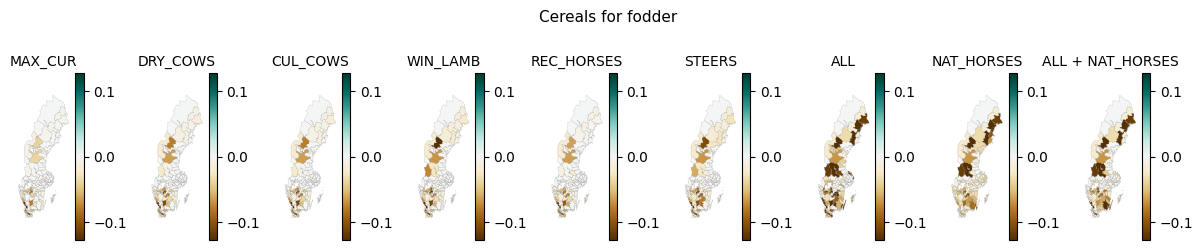

,0,1
scn,,
MAX_CUR,-1.8,-7.1
DRY_COWS,-2.4,-9.0
CUL_COWS,-2.5,-9.3
WIN_LAMB,-2.8,-10.4
REC_HORSES,-2.3,-8.7
STEERS,-2.9,-10.7
ALL,-6.2,-21.9
NAT_HORSES,-3.8,-12.4
ALL + NAT_HORSES,-3.9,-13.2


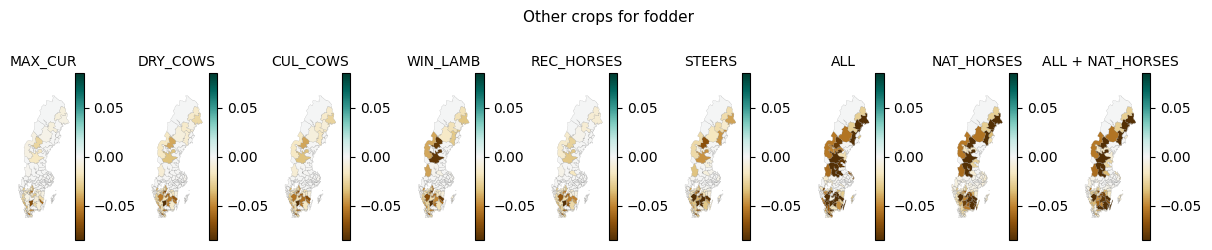

,0,1
scn,,
MAX_CUR,-1.0,-4.7
DRY_COWS,-1.5,-6.9
CUL_COWS,-1.6,-7.2
WIN_LAMB,-1.8,-8.2
REC_HORSES,-1.4,-6.5
STEERS,-2.0,-8.9
ALL,-4.7,-19.5
NAT_HORSES,-3.8,-14.7
ALL + NAT_HORSES,-3.9,-15.3


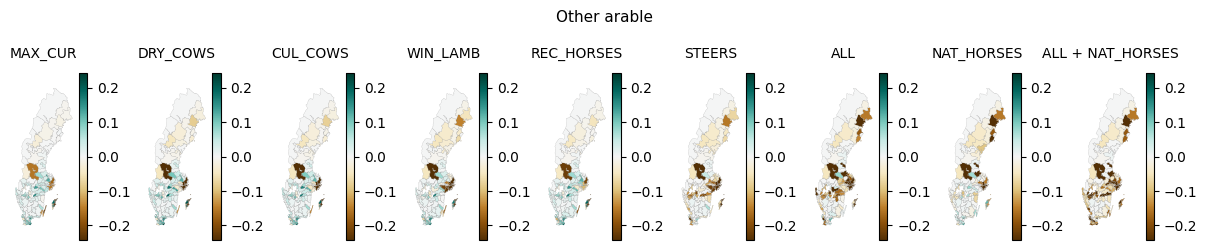

,0,1
scn,,
MAX_CUR,1.2,4.3
DRY_COWS,1.2,5.1
CUL_COWS,0.8,3.7
WIN_LAMB,-1.4,-1.6
REC_HORSES,1.3,4.8
STEERS,-6.4,-18.8
ALL,-8.9,-23.9
NAT_HORSES,-2.8,-5.6
ALL + NAT_HORSES,-11.2,-34.5


In [69]:
d1 = (
    session.get_attr('c','area',{'crop':'crop_group2', 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('BL','0')],axis=1))
    .drop(('BL','0'))
    .droplevel('year')
)/1_000

d2 = (
    session.get_attr('c','area',{'crop':None, 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('BL','0')],axis=1))
    .drop(('BL','0'))
    .droplevel('year')
)/1_000

d3 = (
    session.get_attr('c','production',{'crop':'crop_group2', 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('BL','0')],axis=1))
    .drop(('BL','0'))
    .droplevel('year')
)/1_000_000

d4 = (
    session.get_attr('c','production',{'crop':None, 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('BL','0')],axis=1))
    .drop(('BL','0'))
    .droplevel('year')
)/1_000_000

s = d1.loc[:,'Semi-natural grasslands'].sum(axis=1).sort_values().index
d1 = d1.loc[s]
d2 = d2.loc[s]
d3 = d3.loc[s]
d4 = d4.loc[s]

n_scn = len(d1)

crps = ['Semi-natural grasslands','Cereals','Ley for grazing','Ley for fodder','Cereals for fodder','Other crops for fodder','Other arable']

for crp in crps:
    try:
        d = d1.loc[:,crp]
        p = d3.loc[:,crp]
    except KeyError:
        d = d2.loc[:,crp]
        p = d4.loc[:,crp]
    lim = np.quantile(d.abs(),0.95)
    
    fig, axs = plt.subplots(1,n_scn, figsize=(1.35*n_scn,2.5))
    for i, scn in enumerate(d.index):
        ax=axs[i]
        cm.plot.map_from_series(
            d.loc[scn],
            ax=ax,
            vmin=-lim,
            vmax=lim,
            **map_style_div
        )
        ax.set_title(scn, size=10)
        ax.axis('off')
    plt.suptitle(f'{crp}', size=11)
    plt.tight_layout()
    plt.show()
    display(pd.concat([d.sum(axis=1),p.sum(axis=1)], axis=1).style.format(precision=1))


#### Share of pot. SNG

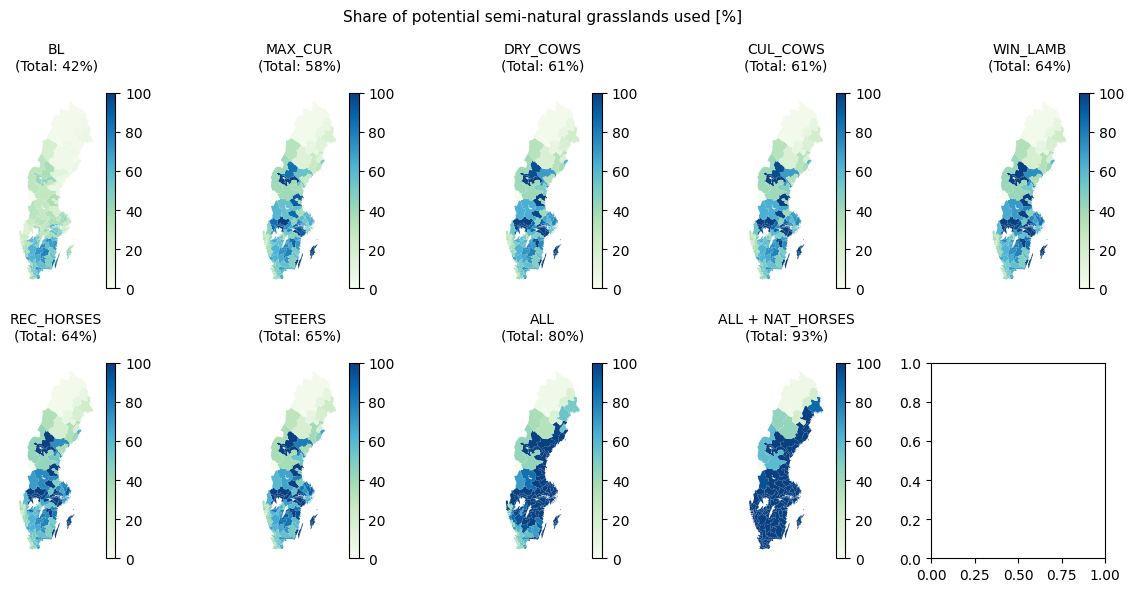

In [83]:
sng_use = session.get_attr('c','area',{'crop':'land_use', 'region':None}).loc[scn_final,'semi-natural grasslands']
sng_pot = session.get_attr('r','max_land_use',['land_use','region']).loc[('MAX_CUR','100'),'semi-natural grasslands']
tot_share = (sng_use.sum(axis=1) / sng_pot.sum()).droplevel('year')*100

plot_data = (
    sng_use.div(sng_pot, axis=1)
    .droplevel('year')
) * 100

fig, axs = plt.subplots(2,5, figsize=(12,6))
for n, scn in enumerate(sort):
    ax = axs.flatten()[n]
    cm.plot.map_from_series(
        plot_data.loc[scn],
        ax = ax,
        vmin=0,
        vmax=100,
        **map_style
    )
    ax.set_title(f'{scn}\n(Total: {tot_share.loc[scn]:.0f}%)', size=10)
    ax.axis('off')
fig.suptitle('Share of potential semi-natural grasslands used [%]', size=11)
plt.tight_layout()
plt.show()

#### Share of max cropland

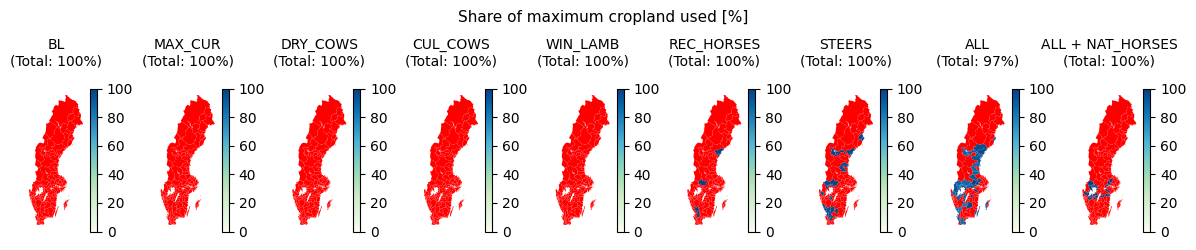

In [84]:
ch4_cap = '110'
cropland_use = session.get_attr('c','area',{'crop':'land_use', 'region':None}).loc[(sort,['0',ch4_cap]),'cropland']
cropland_max = session.get_attr('r','max_land_use',['land_use','region']).loc[('MAX_CUR',ch4_cap),'cropland']
tot_share = (cropland_use.sum(axis=1) / cropland_max.sum()).droplevel('year')*100

plot_data = (
    cropland_use.div(cropland_max, axis=1)
    .droplevel('year')
) * 100

fig, axs = plt.subplots(1,len(sort), figsize=(12,2.5))
for n, scn in enumerate(sort):
    ax = axs[n]
    cm.plot.map_from_series(
        plot_data.loc[scn].where(plot_data.loc[scn]<99.9,np.nan),
        missing_kwds={'color':'red'},
        ax = ax,
        vmin=0,
        vmax=100,
        **map_style
    )
    ax.set_title(f'{scn}\n(Total: {tot_share.loc[scn]:.0f}%)', size=10)
    ax.axis('off')
fig.suptitle('Share of maximum cropland used [%]', size=11)
plt.tight_layout()
plt.show()

In [31]:
a=pd.Series([1,2,3,4,5])
a.where(a<3,np.nan)

0    1.0
1    2.0
2    NaN
3    NaN
4    NaN
dtype: float64

### Maps. Changes in animal herds

In [10]:
scn_final

[('BL', '0'),
 ('MAX_CUR', '100'),
 ('STEERS', '100'),
 ('CUL_COWS', '100'),
 ('DRY_COWS', '100'),
 ('REC_HORSES', '100'),
 ('NAT_HORSES', '100'),
 ('ALL', '100'),
 ('ALL + NAT_HORSES', '100'),
 ('WIN_LAMB', '100')]

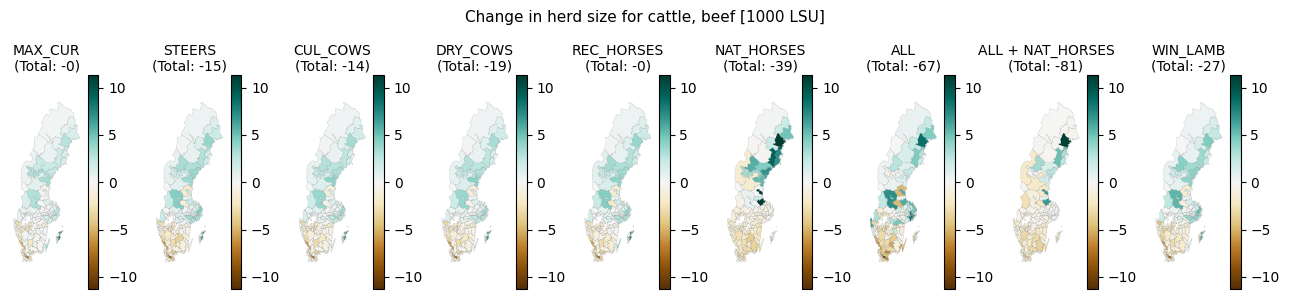

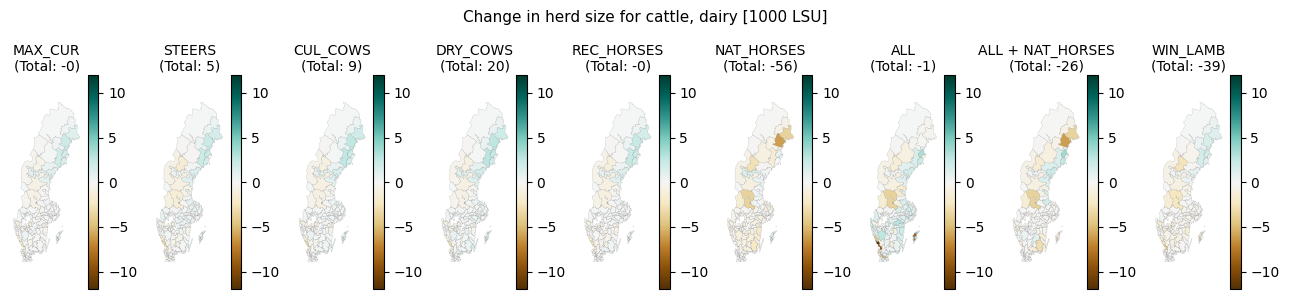

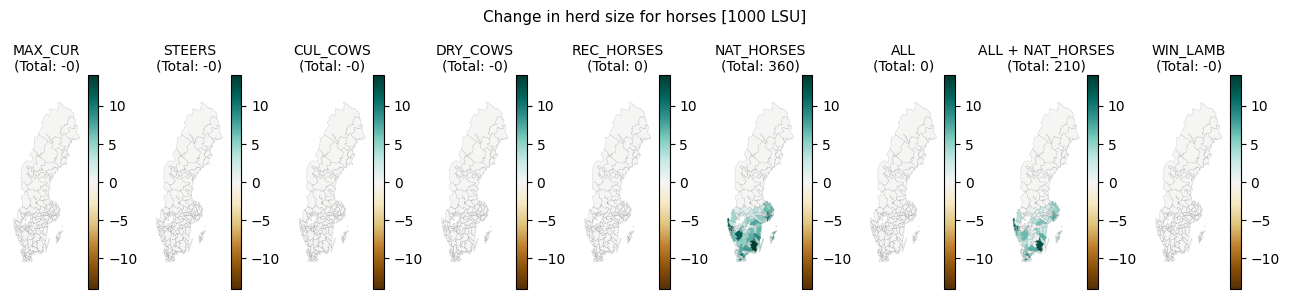

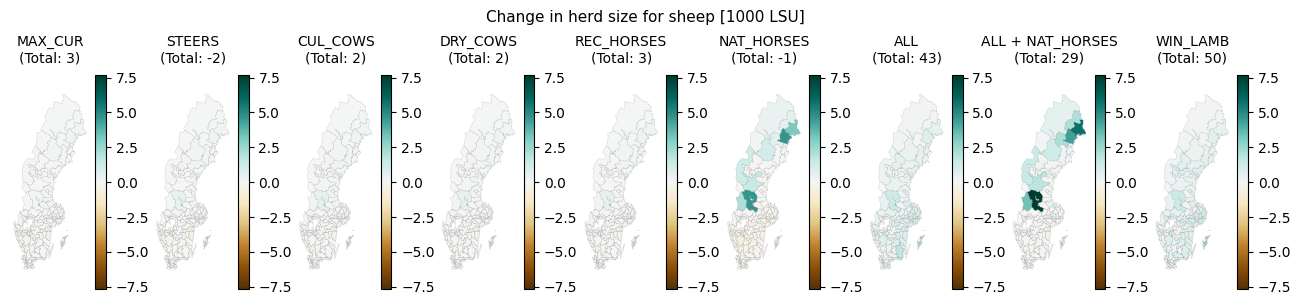

In [9]:
plot_data = (
    cm.impact.get_LSU(session, ['region','species','breed'])
    .loc[scn_final]
    .droplevel('year')
    .transform(lambda x: x.sub(x.loc[('BL')],axis=1))
    .drop('BL')
    .stack('region')
)/1000
plot_data.columns = pd.Index([c[0] if c[0] != 'cattle' else ', '.join(c) for c in plot_data.columns], name='animal_system')
plot_data = plot_data.T.groupby('animal_system').sum().T

plot_data = plot_data.drop(['pigs','poultry'], axis=1)

for ani in plot_data.columns:
    d = plot_data.loc[:,ani]

    lim = max(-min(d.values), max(d.values))
    
    fig, axs = plt.subplots(1,len(d.index.unique('scn')), figsize=(13,3))
    for n, scn in enumerate(d.index.unique('scn')):
        ax = axs[n]
        cm.plot.map_from_series(
            d.loc[scn],
            ax = ax,
            vmin = -lim,
            vmax = lim,
            **map_style_div
        )
        ax.set_title(f'{scn}\n(Total: {d.loc[scn].sum():.0f})', size=10)
        ax.axis('off')
    fig.suptitle(f'Change in herd size for {ani} [1000 LSU]', size=11)
    plt.tight_layout()
    plt.show()

## Sensitivity analysis

In [159]:
session.cache.clear()
session_sens.cache.clear()

In [160]:
do = (
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[(['MAX_CUR','ALL']),'semi-natural grasslands']
)

ds = (
    session_sens.get_attr('c','area',{'crop':['land_use',None]})
    .drop('BL', level='scn')
    .loc[:,'semi-natural grasslands']
)

sens_data = (
    pd.concat([do,ds])
    .div(1_000_000)
    .apply(lambda x: pd.Series({
        'Total' : x.sum(),
        'Open' : x.drop('Semi-natural pastures, wooded').sum(),
        'Wooded' : x.xs('Semi-natural pastures, wooded')
    }), axis=1)
    .unstack('year')
    .rename(columns=rename_years)
)
sens_data.index = pd.MultiIndex.from_tuples(
    [tuple(s.split(' + ')) if '+' in s else (s,'-') for s in sens_data.index],
    names = ['scn', 'sens']
)
sens_data = sens_data.sort_index()
sens_data_prc = sens_data.copy()
sens_data_prc.loc[['MAX_CUR'],:] = sens_data.loc[['MAX_CUR'],:].apply(lambda x: (x-x.loc[('MAX_CUR','-')]) / x.loc[('MAX_CUR','-')] * 100)
sens_data_prc.loc[['ALL'],:] = sens_data.loc[['ALL'],:].apply(lambda x: (x-x.loc[('ALL','-')]) / x.loc[('ALL','-')] * 100)

# Format function
def format_value(val, pct):
    if np.isnan(val):
        return ""
    else:
        return f"{val:.2f} ({pct:+.0f}%)"

# Apply formatting element-wise
sens_table = pd.DataFrame(
    [[format_value(v, p) for v, p in zip(v_row, p_row)] 
     for v_row, p_row in zip(sens_data.values, sens_data_prc.values)],
    index=sens_data.index,
    columns=sens_data.columns
)


sens_table.loc[['MAX_CUR','ALL']].to_clipboard()
sens_table.loc[['MAX_CUR','ALL']]

Total                                   Open  \
year                    -30% CH$_4$   ±0% CH$_4$  +10% CH$_4$  -30% CH$_4$   
scn     sens                                                                 
MAX_CUR -                0.48 (+0%)   0.73 (+0%)   0.81 (+0%)   0.47 (+0%)   
        FIX_ANI                       0.69 (-6%)                             
ALL     -                0.72 (+0%)   1.01 (+0%)   1.10 (+0%)   0.70 (+0%)   
        HIGH_SHARE_SNG  1.03 (+42%)  1.19 (+18%)   1.19 (+9%)  0.99 (+42%)   
        LOW_YIELDS      0.96 (+33%)  1.18 (+17%)   1.18 (+7%)  0.92 (+32%)   
        MORE_CROPLAND    0.72 (+0%)   1.01 (+0%)   1.10 (+0%)   0.70 (+0%)   
        MORE_POT         0.74 (+3%)   1.03 (+2%)   1.12 (+3%)   0.71 (+3%)   
        MORE_WOODED     0.83 (+15%)  1.18 (+17%)  1.29 (+18%)  0.60 (-14%)   

                                                        Wooded                \
year                     ±0% CH$_4$  +10% CH$_4$   -30% CH$_4$    ±0% CH$_4$   
scn     sens                                                                   
MAX_CUR -                0.70 (+0%)   0.78 (+0%)    0.01 (+0%)    0.03 (+0%)   
        FIX_ANI          0.67 (-5%)                              0.02 (-16%)   
ALL     -                0.97 (+0%)   1.06 (+0%)    0.03 (+0%)    0.04 (+0%)   
        HIGH_SHARE_SNG  1.15 (+18%)   1.15 (+9%)   0.04 (+59%)   0.04 (+16%)   
        LOW_YIELDS      1.14 (+17%)   1.14 (+8%)   0.04 (+43%)   0.04 (+13%)   
        MORE_CROPLAND    0.97 (+0%)   1.06 (+0%)    0.03 (+1%)    0.04 (+3%)   
        MORE_POT         0.99 (+2%)   1.08 (+3%)    0.03 (+4%)    0.04 (+4%)   
        MORE_WOODED     0.86 (-12%)  0.94 (-11%)  0.23 (+828%)  0.33 (+775%)   

                                      
year                     +10% CH$_4$  
scn     sens                          
MAX_CUR -                 0.03 (+0%)  
        FIX_ANI                       
ALL     -                 0.04 (+0%)  
        HIGH_SHARE_SNG    0.04 (+8%)  
        LOW_YIELDS        0.04 (+5%)  
        MORE_CROPLAND     0.04 (+2%)  
        MORE_POT          0.04 (+4%)  
        MORE_WOODED     0.35 (+773%)

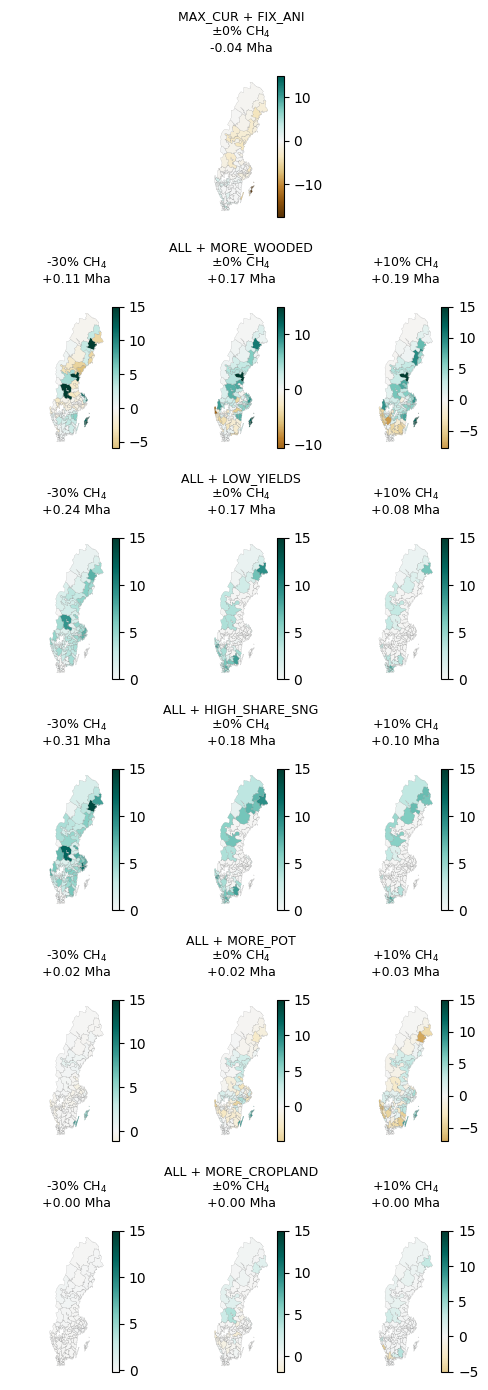

In [161]:
do = (
    session.get_attr('c','area',{'crop':'land_use','region':None})
    .loc[(['MAX_CUR','ALL']),'semi-natural grasslands']
)/1_000

ds = (
    session_sens.get_attr('c','area',{'crop':'land_use','region':None})
    .loc[:,'semi-natural grasslands']
    .drop('BL', level='scn')
)/1_000

fig,axs = plt.subplots(len(ds.index.unique('scn')), len(ds.index.unique('year')), figsize=(5,14))

for i,s in enumerate(ds.index.unique('scn')):
    for j,y in enumerate(['70','100','110']):
        ax = axs[i,j]
        if (s,y) in ds.index:
            d = ds.loc[(s,y)] - do.loc[(s.split(' + ')[0], y)]
            cm.plot.map_from_series(
                d,
                cmap_zero_midpoint='shrink',
                ax=ax,
                vmax=15,
                **map_style_div
            )
            if y == '100':
                ax.set_title('\n'.join([s,rename_years[y],f"{d.sum()/1_000:+.2f} Mha"]), size=9)
            else:
                ax.set_title('\n'.join([' ',rename_years[y],f"{d.sum()/1_000:+.2f} Mha"]), size=9)
        ax.axis('off')
plt.tight_layout()
plt.show()
    